## LSTM Model - BG Forecasting

In [1]:
!pip install -r ../requirements.txt

## 30 Minutes - Prediction Horizon

Using past 12 steps to predict next 6 steps.
Subject chosen: 540
Total records for subject: 14842
Using features: ['carbs', 'bolus', 'basal', 'galvanic_skin_response', 'skin_temp', 'acceleration', 'workout_intensity', 'workout_duration', 'is_test', 'heartrate', 'air_temp', 'steps']


c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\sklearn\utils\_array_api.py:686: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\sklearn\utils\_array_api.py:706: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


Built sequences -> X: (14825, 12, 12) y: (14825, 6)
Approx supervised train samples: 11861
Final shapes -> X_train: (11861, 12, 12) y_train: (11861, 6) X_test: (2964, 12, 12) y_test: (2964, 6)
n_past, n_future, n_features: 12 6 12


c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_21 (LSTM)                  │ (None, 64)             │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,990 (85.90 KB)

 Trainable params: 21,990 (85.90 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0415 - val_loss: 0.0344
Epoch 2/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0265 - val_loss: 0.0343
Epoch 3/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0265 - val_loss: 0.0343
Epoch 4/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0265 - val_loss: 0.0344
Epoch 5/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0265 - val_loss: 0.0344
Epoch 6/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0265 - val_loss: 0.0344
Epoch 7/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0265 - val_loss: 0.0344
Epoch 8/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0265 - val_loss: 0.0344
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 2.
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Results (flattened across horizon):
 LSTM   -> MSE: 5267.971, MAE: 55.179
 Persist-> MSE: 387.050, MAE: 13.179
Per-horizon MSE / MAE:
  horizon t+5min -> MSE: 5280.594, MAE: 55.209
 

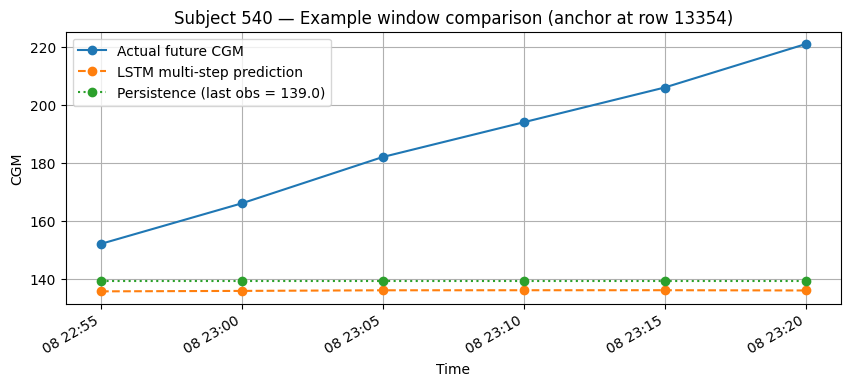

In [11]:
# CELL 1: imports + config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# reproducibility
RND = 42
np.random.seed(RND)
tf.random.set_seed(RND)

# configuration
DATA_PATH = "../data/OhioT1DM.csv"
SUBJECT_TO_USE = None   # None -> pick first subject id found
STEP_MIN = 5            # sampling period in minutes
PRED_HORIZ_MIN = 30     # how far ahead to predict (minutes)
PAST_WINDOW_MIN = 60    # how many minutes of history to use (window)
TEST_FRACTION = 0.2     # fraction of subject time series used as test (last 20%)
BATCH_SIZE = 16
EPOCHS = 100
PATIENCE = 6
VERBOSE = 1

# derived
n_future = PRED_HORIZ_MIN // STEP_MIN         # number of future timesteps to predict
n_past = PAST_WINDOW_MIN // STEP_MIN         # number of past timesteps to feed into LSTM
print(f"Using past {n_past} steps to predict next {n_future} steps.")
# CELL 2: load + basic cleaning
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df = df.sort_values(['id','date']).reset_index(drop=True)

# drop rows where CGM is missing (we can't train/evaluate on missing targets)
df = df.dropna(subset=['CGM']).reset_index(drop=True)

# pick subject
subject_ids = df['id'].unique()
if SUBJECT_TO_USE is None:
    subject_id = subject_ids[0]
else:
    subject_id = SUBJECT_TO_USE
print("Subject chosen:", subject_id)

sub = df[df['id'] == subject_id].copy().reset_index(drop=True)
print("Total records for subject:", len(sub))
if len(sub) < (n_past + n_future + 10):
    raise ValueError("Not enough samples for the chosen subject. Reduce window/horizon or pick another subject.")
# CELL 3: feature selection + scaling
# choose numeric features to use as multi-input. Drop identity fields.
drop_cols = ['date','id','insulin_type','gender']   # can be modified to include encoded categorical features
feature_cols = [c for c in sub.columns if c not in drop_cols + ['CGM']]

print("Using features:", feature_cols)

# Fill small gaps (if you want) - here we'll forward-fill numeric features, then drop any remaining NaNs
sub[feature_cols + ['CGM']] = sub[feature_cols + ['CGM']].ffill().bfill()
sub = sub.dropna(subset=['CGM']).reset_index(drop=True)

# scalers (fit on train only later — but we need scalers defined now)
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

# We'll split into train/test first, then fit scalers on train to avoid leakage.
split_idx = int((1 - TEST_FRACTION) * len(sub))
train_df = sub.iloc[:split_idx].reset_index(drop=True)
test_df  = sub.iloc[split_idx:].reset_index(drop=True)

# Fit scalers on training portion
X_train_vals = train_df[feature_cols].values
y_train_vals = train_df[['CGM']].values

X_scaler.fit(X_train_vals)
y_scaler.fit(y_train_vals)

# Apply scaling to whole subject (we will use scaled arrays when building sequences)
sub_scaled = sub.copy()
sub_scaled[feature_cols] = X_scaler.transform(sub[feature_cols].values)
sub_scaled['CGM'] = y_scaler.transform(sub[['CGM']].values)
# CELL 4: sequence builder for multi-step, multi-input
def build_sequences(df_scaled, feature_cols, target_col='CGM', n_past=12, n_future=6):
    """
    Build supervised sequences:
      X shape -> (samples, n_past, n_features)
      y shape -> (samples, n_future)
    We assume consecutive rows correspond to consecutive time-steps (uniform sampling).
    """
    X, y = [], []
    total_len = len(df_scaled)
    for end_idx in range(n_past - 1, total_len - n_future):
        start_idx = end_idx - (n_past - 1)
        X_seq = df_scaled.iloc[start_idx:end_idx+1][feature_cols].values
        y_seq = df_scaled.iloc[end_idx+1 : end_idx+1 + n_future][target_col].values  # shape (n_future,)
        if X_seq.shape[0] == n_past and y_seq.shape[0] == n_future:
            X.append(X_seq)
            y.append(y_seq)
    X = np.array(X)
    y = np.array(y)
    return X, y

# build sequences from scaled dataframe
X_all, y_all = build_sequences(sub_scaled, feature_cols, 'CGM', n_past=n_past, n_future=n_future)
print("Built sequences -> X:", X_all.shape, "y:", y_all.shape)

# Now split X_all/y_all into train/test according to the split index we computed earlier.
# We need to map sample indices back to original df rows: the first supervised sample uses rows [0..n_past-1] -> label starts at n_past
# So supervised sample i corresponds to end_idx = n_past-1 + i. So we can compute the number of supervised samples in train by
first_label_index = n_past  # the y for the first sample is at row index n_past
# compute number of supervised samples whose label row < split_idx (i.e., belong to train)
train_samples = max(0, split_idx - first_label_index)
print("Approx supervised train samples:", train_samples)

X_train = X_all[:train_samples]
y_train = y_all[:train_samples]
X_test  = X_all[train_samples:]
y_test  = y_all[train_samples:]

print("Final shapes -> X_train:", X_train.shape, "y_train:", y_train.shape, "X_test:", X_test.shape, "y_test:", y_test.shape)

if X_train.shape[0] < 10:
    print("Warning: very few train samples; consider reducing windows or using more subjects.")
# CELL 5: build the LSTM model
n_features = X_train.shape[2]
print("n_past, n_future, n_features:", n_past, n_future, n_features)

def make_lstm_model(n_past, n_features, n_future):
    model = Sequential()
    model.add(LSTM(64, input_shape=(n_past, n_features), return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(n_future, activation='linear'))   # predict raw scaled CGM for each horizon step
    model.compile(optimizer='adam', loss='mse')
    return model

model = make_lstm_model(n_past, n_features, n_future)
model.summary()
# CELL 6: train the model
es = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es],
    verbose=VERBOSE
)
# CELL 7: predict on test set, invert scaling, compute metrics, compare to persistence baseline
# predict (scaled)
y_pred_scaled = model.predict(X_test)

# invert scaling: y_scaler was fit on single-column CGM; to inverse_transform we need shape (n_samples*n_future, 1)
y_pred_flat = y_pred_scaled.reshape(-1, 1)
y_test_flat = y_test.reshape(-1, 1)

y_pred_inv = y_scaler.inverse_transform(y_pred_flat).ravel()
y_test_inv = y_scaler.inverse_transform(y_test_flat).ravel()

mse_lstm = mean_squared_error(y_test_inv, y_pred_inv)
mae_lstm = mean_absolute_error(y_test_inv, y_pred_inv)

# persistence baseline (zero-order hold): last observed CGM of anchor is X_test's last timestep target (we must get it in original scale)
# For each X_test sample, the last observed CGM corresponds to the last row of the original (pre-scaled) 'CGM' at the anchor.
# We can reconstruct using y_scaler and the scaled CGM last value from X_test features is NOT present (we used only other features).
# Instead, rebuild anchor last CGM from the unscaled sub data: easiest is to rebuild anchors in the unscaled series.
# Simpler approach: compute persistence predictions by taking y_true's first past-step true value in original series.
# We'll reconstruct anchor index mapping to original dataframe to get last observed CGM for each anchor:
# anchor_end_idx for supervised sample i = n_past - 1 + i

anchor_end_indices = np.arange(n_past - 1, n_past - 1 + X_all.shape[0])  # end_idx for all supervised samples (relative to sub)
anchor_end_indices_test = anchor_end_indices[train_samples:]  # indices for test supervised samples

# last observed CGM values (original scale)
last_cgms = sub.loc[anchor_end_indices_test, 'CGM'].values  # these are original unscaled CGM values (since sub is original)
# persistence replicate for n_future steps and flatten
y_persistence_flat = np.repeat(last_cgms[:, None], n_future, axis=1).reshape(-1)

mse_persist = mean_squared_error(y_test_inv, y_persistence_flat)
mae_persist = mean_absolute_error(y_test_inv, y_persistence_flat)

print("Results (flattened across horizon):")
print(f" LSTM   -> MSE: {mse_lstm:.3f}, MAE: {mae_lstm:.3f}")
print(f" Persist-> MSE: {mse_persist:.3f}, MAE: {mae_persist:.3f}")
# CELL 8: per-horizon metrics (optional) + printing count
# compute metrics per horizon step (1..n_future)
y_test_by_h = y_test.reshape(-1, n_future)  # scaled -> need inverse
y_pred_by_h = y_pred_scaled.reshape(-1, n_future)
y_test_by_h_inv = y_scaler.inverse_transform(y_test_by_h.reshape(-1,1)).reshape(-1, n_future)
y_pred_by_h_inv = y_scaler.inverse_transform(y_pred_by_h.reshape(-1,1)).reshape(-1, n_future)

print("Per-horizon MSE / MAE:")
for h in range(n_future):
    mse_h = mean_squared_error(y_test_by_h_inv[:,h], y_pred_by_h_inv[:,h])
    mae_h = mean_absolute_error(y_test_by_h_inv[:,h], y_pred_by_h_inv[:,h])
    mse_p_h = mean_squared_error(y_test_by_h_inv[:,h], np.repeat(last_cgms, 1)) if False else None  # skip direct persistence per-horizon here
    print(f"  horizon t+{(h+1)*STEP_MIN}min -> MSE: {mse_h:.3f}, MAE: {mae_h:.3f}")
# CELL 9: visualize an example window comparing actual vs LSTM vs persistence baseline
example_idx = max(0, X_test.shape[0] // 2)  # middle window in test split
# get anchor end index in original df and its future times
anchor_end_idx = anchor_end_indices_test[example_idx]
future_rows = sub.iloc[anchor_end_idx+1 : anchor_end_idx+1 + n_future]
times_future = future_rows['date'].values
actual_future = future_rows['CGM'].values

# LSTM predicted (inverse scaled)
pred_scaled_example = y_pred_scaled[example_idx]         # shape (n_future,)
pred_example = y_scaler.inverse_transform(pred_scaled_example.reshape(-1,1)).ravel()

# persistence predicted
persist_val = sub.loc[anchor_end_idx, 'CGM']
persist_pred = np.repeat(persist_val, n_future)

plt.figure(figsize=(10,4))
plt.plot(times_future, actual_future, marker='o', linestyle='-', label='Actual future CGM')
plt.plot(times_future, pred_example, marker='o', linestyle='--', label='LSTM multi-step prediction')
plt.plot(times_future, persist_pred, marker='o', linestyle=':', label=f'Persistence (last obs = {persist_val:.1f})')
plt.xlabel('Time')
plt.ylabel('CGM')
plt.title(f'Subject {subject_id} — Example window comparison (anchor at row {anchor_end_idx})')
plt.legend()
plt.grid(True)
plt.gcf().autofmt_xdate()
plt.show()


In [3]:
# CELL 10: optional: show a small table of a few predicted windows (anchor_time, last_cgm, actual first future, predicted first future)
display_rows = min(6, X_test.shape[0])
out = []
for i in range(display_rows):
    a_idx = anchor_end_indices_test[i]
    out.append({
        "anchor_time": sub.loc[a_idx, 'date'],
        "last_cgm": sub.loc[a_idx, 'CGM'],
        "actual_first_future": sub.loc[a_idx+1, 'CGM'],
        "pred_first_future": float(y_scaler.inverse_transform(y_pred_scaled[i,0].reshape(1,1)).ravel()[0])
    })
display(pd.DataFrame(out))


,anchor_time,last_cgm,actual_first_future,pred_first_future
0,2027-07-03 17:55:00,236.0,238.0,137.051147
1,2027-07-03 18:00:00,238.0,240.0,137.051147
2,2027-07-03 18:05:00,240.0,242.0,137.051147
3,2027-07-03 18:10:00,242.0,243.0,137.051147
4,2027-07-03 18:15:00,243.0,243.0,137.051147
5,2027-07-03 18:20:00,243.0,244.0,137.051147


Lookback steps: 12 | Prediction steps: 6
Using subject: 540
Using AUX: ['carbs', 'bolus', 'basal', 'galvanic_skin_response', 'skin_temp', 'acceleration', 'workout_intensity', 'workout_duration', 'heartrate', 'air_temp', 'steps']
Windows: (14825, 12, 1)
Train: 11860 Test: 2965


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 12, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 12, 11)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_10        │ (None, 12, 1)     │          0 │ input_layer_4[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_11        │ (None, 12, 11)    │          0 │ input_layer_5[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_10          │ (None, 12, 1)     │          0 │ input_layer_4[0]… │
│ (Masking)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_10 (Any)        │ (None, 12)        │          0 │ not_equal_10[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_11          │ (None, 12, 11)    │          0 │ input_layer_5[0]… │
│ (Masking)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_11 (Any)        │ (None, 12)        │          0 │ not_equal_11[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_22 (LSTM)      │ (None, 12, 64)    │     16,896 │ masking_10[0][0], │
│                     │                   │            │ any_10[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_24 (LSTM)      │ (None, 12, 64)    │     19,456 │ masking_11[0][0], │
│                     │                   │            │ any_11[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 12, 64)    │          0 │ lstm_22[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 12, 64)    │          0 │ lstm_24[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_23 (LSTM)      │ (None, 32)        │     12,416 │ dropout_17[0][0], │
│                     │                   │            │ any_10[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_25 (LSTM)      │ (None, 32)        │     12,416 │ dropout_18[0][0], │
│                     │                   │            │ any_11[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 64)        │          0 │ lstm_23[0][0],    │
│ (Concatenate)       │                   │            │ lstm_25[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128)       │      8,320 │ concatenate_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 128)       │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 6)         │        774 │ dropout_19[0][0]

 Total params: 70,278 (274.52 KB)

 Trainable params: 70,278 (274.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 0.1708 - val_loss: 0.0763 - learning_rate: 0.0010
Epoch 2/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0953 - val_loss: 0.0665 - learning_rate: 0.0010
Epoch 3/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0860 - val_loss: 0.0661 - learning_rate: 0.0010
Epoch 4/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0818 - val_loss: 0.0629 - learning_rate: 0.0010
Epoch 5/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0780 - val_loss: 0.0655 - learning_rate: 0.0010
Epoch 6/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0758 - val_loss: 0.0664 - learning_rate: 0.0010
Epoch 7/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0736 - val_loss: 0.0660 - learning_rate: 0.0010
Epoch 8/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0730 - val_loss: 0.0650 - learning_rate: 0.0010
Epoch 9/100
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0656 - val_loss: 0.0624 - learning_rate: 1

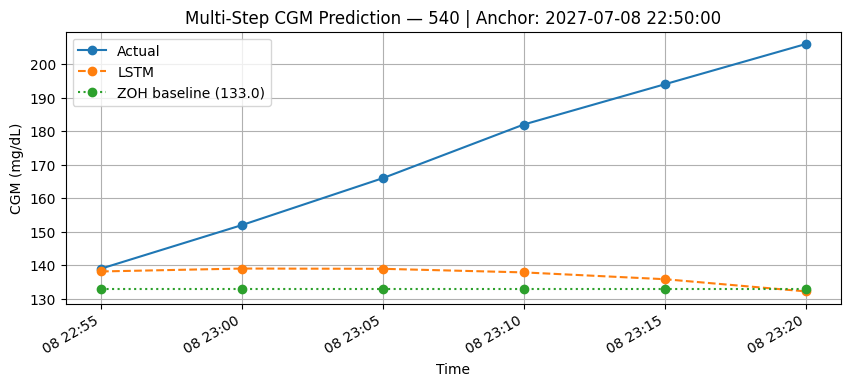

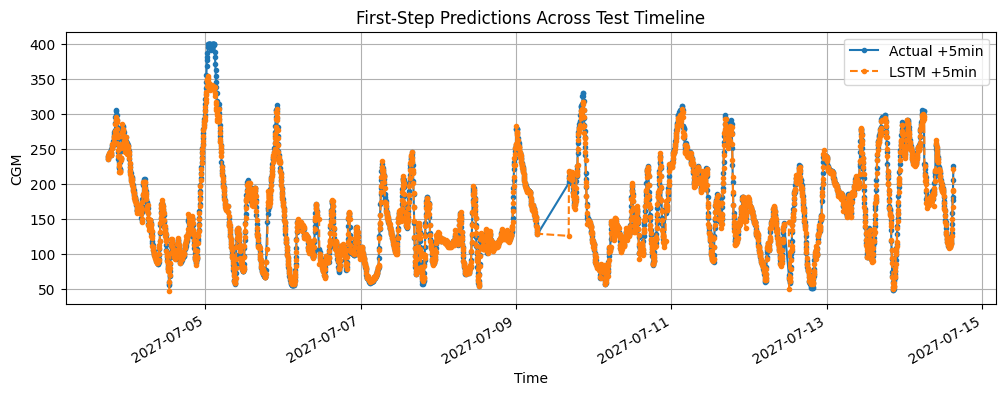

In [12]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, concatenate, Masking, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import random, os

# ✅ Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# ✅ Configuration
DATA_PATH = "../data/OhioT1DM.csv"
SUBJECT_ID = None    # None -> picks the first subject
LOOKBACK_MIN = 60    # past window (minutes)
PRED_HORIZ_MIN = 30  # forecast horizon (minutes)
STEP_MIN = 5
TEST_FRACTION = 0.2
BATCH_SIZE = 16
EPOCHS = 100
LSTM_UNITS = 64
DROPOUT = 0.2

LOOKBACK_STEPS = LOOKBACK_MIN // STEP_MIN
N_PRED_STEPS = PRED_HORIZ_MIN // STEP_MIN

print("Lookback steps:", LOOKBACK_STEPS,
      "| Prediction steps:", N_PRED_STEPS)

# ✅ Load data
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df = df.sort_values(['id', 'date']).reset_index(drop=True)

# ✅ Select subject
if SUBJECT_ID is None:
    SUBJECT_ID = df['id'].unique()[0]
print("Using subject:", SUBJECT_ID)
sub = df[df['id'] == SUBJECT_ID].copy().reset_index(drop=True)

# ✅ Drop rows missing CGM
sub = sub.dropna(subset=['CGM']).reset_index(drop=True)

# ✅ Auxiliary features
aux_features = [
    'carbs','bolus','basal','galvanic_skin_response','skin_temp','acceleration',
    'workout_intensity','workout_duration','heartrate','air_temp','steps'
]
aux_features = [c for c in aux_features if c in sub.columns]
print("Using AUX:", aux_features)

sub[aux_features] = sub[aux_features].fillna(0.0)
sub['CGM'] = sub['CGM'].astype(float)

# ✅ Build sliding windows
def build_windows(data, lb, ph):
    X_cgm, X_aux, Y, times = [], [], [], []
    for i in range(len(data) - (lb + ph) + 1):
        seq = data.iloc[i:i + lb]
        future = data.iloc[i + lb:i + lb + ph]
        if future['CGM'].isnull().any():
            continue
        X_cgm.append(seq['CGM'].values.reshape(-1,1))
        X_aux.append(seq[aux_features].values)
        Y.append(future['CGM'].values)
        times.append(data.iloc[i + lb]['date'])
    return np.array(X_cgm), np.array(X_aux), np.array(Y), np.array(times)

X_cgm, X_aux, Y, T = build_windows(sub, LOOKBACK_STEPS, N_PRED_STEPS)
print("Windows:", X_cgm.shape)

# ✅ Train/test split
split = int(len(X_cgm)*(1-TEST_FRACTION))
X_cgm_tr, X_cgm_te = X_cgm[:split], X_cgm[split:]
X_aux_tr, X_aux_te = X_aux[:split], X_aux[split:]
Y_tr, Y_te = Y[:split], Y[split:]
T_te = T[split:]

print("Train:", len(X_cgm_tr), "Test:", len(X_cgm_te))

# ✅ Scaling
sc_cgm = StandardScaler().fit(X_cgm_tr.reshape(-1,1))
sc_aux = StandardScaler().fit(X_aux_tr.reshape(-1, X_aux_tr.shape[2]))
sc_y   = StandardScaler().fit(Y_tr.reshape(-1,1))

def scale(Xcgm, Xaux, Yy=None):
    Xcs = sc_cgm.transform(Xcgm.reshape(-1,1)).reshape(Xcgm.shape)
    Xas = sc_aux.transform(Xaux.reshape(-1, Xaux.shape[2])).reshape(Xaux.shape)
    if Yy is not None:
        Ys = sc_y.transform(Yy.reshape(-1,1)).reshape(Yy.shape)
        return Xcs, Xas, Ys
    return Xcs, Xas

Xc_tr_s, Xa_tr_s, Y_tr_s = scale(X_cgm_tr, X_aux_tr, Y_tr)
Xc_te_s, Xa_te_s, Y_te_s = scale(X_cgm_te, X_aux_te, Y_te)

# ✅ Build dual-input LSTM
input_cgm = Input(shape=(LOOKBACK_STEPS,1))
x1 = Masking()(input_cgm)
x1 = LSTM(LSTM_UNITS,return_sequences=True)(x1)
x1 = Dropout(DROPOUT)(x1)
x1 = LSTM(LSTM_UNITS//2)(x1)

input_aux = Input(shape=(LOOKBACK_STEPS,X_aux.shape[2]))
x2 = Masking()(input_aux)
x2 = LSTM(LSTM_UNITS,return_sequences=True)(x2)
x2 = Dropout(DROPOUT)(x2)
x2 = LSTM(LSTM_UNITS//2)(x2)

x = concatenate([x1,x2])
x = Dense(128,activation='relu')(x)
x = Dropout(DROPOUT)(x)
output = Dense(N_PRED_STEPS)(x)

model = Model(inputs=[input_cgm,input_aux], outputs=output)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')
model.summary()

# ✅ Train model
val_split = int(0.9 * len(Xc_tr_s))
history = model.fit(
    [Xc_tr_s[:val_split], Xa_tr_s[:val_split]], Y_tr_s[:val_split],
    validation_data=([Xc_tr_s[val_split:], Xa_tr_s[val_split:]], Y_tr_s[val_split:]),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(patience=6,restore_best_weights=True),
               ReduceLROnPlateau(patience=4)],
    verbose=1
)

# ✅ Predict + inverse scale
Y_pred_s = model.predict([Xc_te_s, Xa_te_s], batch_size=BATCH_SIZE)
Y_pred = sc_y.inverse_transform(Y_pred_s.reshape(-1,1)).reshape(Y_pred_s.shape)
Y_true = Y_te

# ✅ Metrics
print("--- METRICS ---")
print("Flattened MSE:", mean_squared_error(Y_true.ravel(), Y_pred.ravel()))
print("Flattened MAE:", mean_absolute_error(Y_true.ravel(), Y_pred.ravel()))

# ✅ Per-step metrics
print("\nStep-wise metrics:")
for i in range(N_PRED_STEPS):
    mse_i = mean_squared_error(Y_true[:,i], Y_pred[:,i])
    mae_i = mean_absolute_error(Y_true[:,i], Y_pred[:,i])
    print(f" +{STEP_MIN*(i+1)} min -> MSE: {mse_i:.2f} | MAE: {mae_i:.2f}")

# ✅ Plot a single sample (mid test)
idx = len(Xc_te_s)//2
anchor_time = T_te[idx]
future_times = [anchor_time + pd.Timedelta(minutes=STEP_MIN*(i+1))
                for i in range(N_PRED_STEPS)]

# Zero-order hold baseline
last_val = X_cgm_te[idx][-1,0]
y_zero = np.repeat(last_val, N_PRED_STEPS)

plt.figure(figsize=(10,4))
plt.plot(future_times, Y_true[idx], 'o-', label='Actual')
plt.plot(future_times, Y_pred[idx], 'o--', label='LSTM')
plt.plot(future_times, y_zero,  'o:', label=f'ZOH baseline ({last_val:.1f})')
plt.grid(); plt.legend()
plt.title(f'Multi-Step CGM Prediction — {SUBJECT_ID} | Anchor: {anchor_time}')
plt.xlabel("Time"); plt.ylabel("CGM (mg/dL)")
plt.gcf().autofmt_xdate()
plt.show()

# ✅ Quick curve for first-step predictions over whole test set
plt.figure(figsize=(12,4))
plt.plot(T_te, Y_true[:,0], '.-', label='Actual +5min')
plt.plot(T_te, Y_pred[:,0], '.--', label='LSTM +5min')
plt.grid(); plt.legend()
plt.title('First-Step Predictions Across Test Timeline')
plt.ylabel("CGM"); plt.xlabel("Time")
plt.gcf().autofmt_xdate()
plt.show()


## Hyperparameter tuning


## Model For Development

Epoch 1/10


c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7255/7255 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - loss: 0.0306
Epoch 2/10
7255/7255 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - loss: 0.0286
Epoch 3/10
7255/7255 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - loss: 0.0286
Epoch 4/10
7255/7255 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - loss: 0.0286
Epoch 5/10
7255/7255 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - loss: 0.0286
Epoch 6/10
7255/7255 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - loss: 0.0286
Epoch 7/10
7255/7255 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - loss: 0.0286
Epoch 8/10
7255/7255 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - loss: 0.0286
Epoch 9/10
7255/7255 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - loss: 0.0286
Epoch 10/10
7255/7255 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - loss: 0.0286


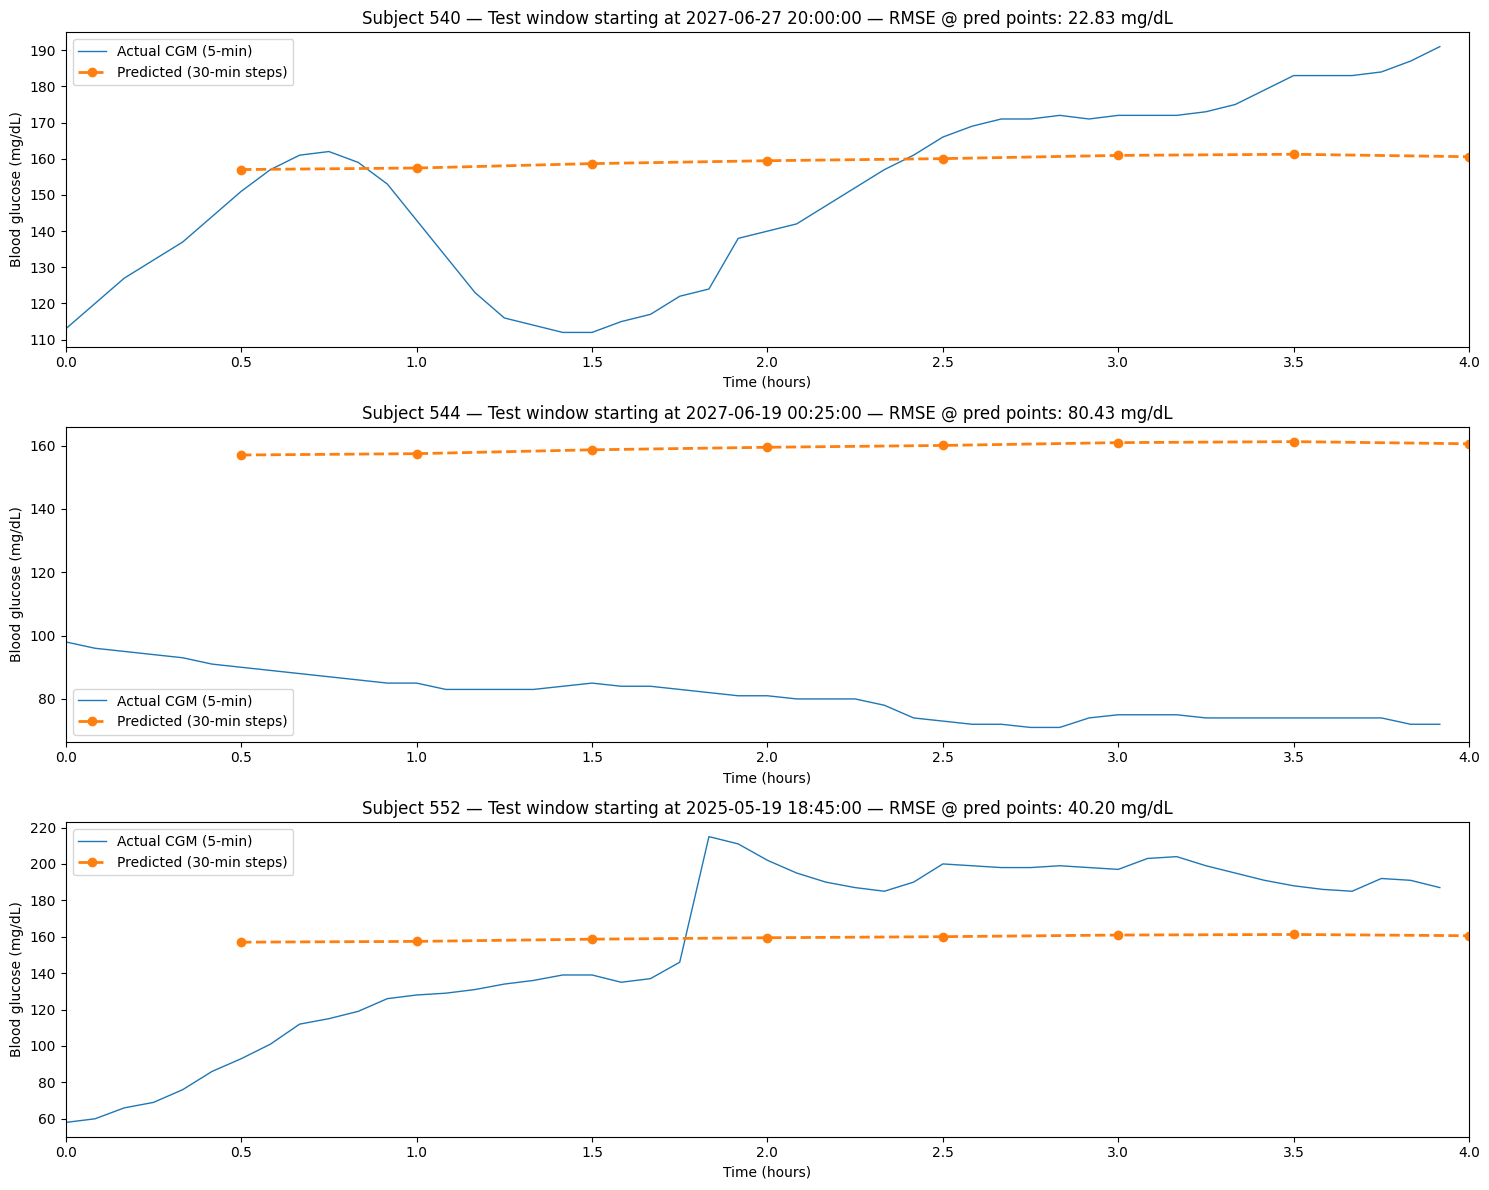

In [35]:
# Single-cell LSTM multi-step multi-input CGM forecast (30-min horizon, up to 4 hours)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
tf.random.set_seed(0); np.random.seed(0)

# ---- Parameters (easy to change) ----
DATA_PATH = "../data/OhioT1DM.csv"
TIME_COL = "date"; ID_COL = "id"; CGM_COL = "CGM"
FEATURES = ["CGM","carbs","bolus","basal","galvanic_skin_response","skin_temp",
            "acceleration","workout_intensity","workout_duration","heartrate","air_temp","steps"]
FREQ_MIN = 5                      # sampling interval of CGM (minutes)
PRED_HORIZON_MIN = 30             # prediction horizon per step (minutes)
STEP_BETWEEN_PREDS = PRED_HORIZON_MIN // FREQ_MIN  # samples between predictions (6)
N_PRED_STEPS = (4*60) // PRED_HORIZON_MIN         # up to 4 hours / 30-min -> 8
LOOKBACK_MIN = 60                 # input window minutes (changeable)
N_INPUT = LOOKBACK_MIN // FREQ_MIN
TRAIN_FRAC = 0.7
EPOCHS = 10
BATCH = 16
LSTM_UNITS = 128

# ---- Load & preprocess ----
df = pd.read_csv(DATA_PATH, parse_dates=[TIME_COL])
df = df.sort_values([ID_COL, TIME_COL]).reset_index(drop=True)
df = df.dropna(subset=[CGM_COL])                   # keep it simple: drop missing CGM rows
df = df[[TIME_COL, ID_COL] + FEATURES]

# build sliding windows per subject and keep start index for plotting
X_train=[]; y_train=[]
X_test=[]; y_test=[]; test_meta=[]
for sid, g in df.groupby(ID_COL):
    g = g.reset_index(drop=True)
    arr = g[FEATURES].values
    n = len(arr)
    max_i = n - N_INPUT - STEP_BETWEEN_PREDS * N_PRED_STEPS + 1
    if max_i <= 0: 
        continue
    Xs=[]; ys=[]; starts=[]
    for i in range(max_i):
        Xs.append(arr[i:i+N_INPUT])
        ys.append([arr[i + N_INPUT + STEP_BETWEEN_PREDS*k - 1, 0]  # CGM is first feature
                   for k in range(1, N_PRED_STEPS+1)])
        starts.append(i)
    Xs = np.array(Xs); ys = np.array(ys)
    split = int(len(Xs) * TRAIN_FRAC)
    X_train.append(Xs[:split]); y_train.append(ys[:split])
    X_test.append(Xs[split:]); y_test.append(ys[split:])
    # store metadata for test samples so we can plot later (subject dataframe + starts for test windows)
    test_meta.append((sid, g, starts[split:] if len(starts)>split else []))

if len(X_train)==0:
    raise RuntimeError("No windows created (dataset too short or params).")

X_train = np.vstack(X_train); y_train = np.vstack(y_train)
X_test_all = np.vstack(X_test) if len(X_test)>0 else np.empty((0,N_INPUT,len(FEATURES)))
y_test_all = np.vstack(y_test) if len(y_test)>0 else np.empty((0,N_PRED_STEPS))

# ---- Scaling (fit only on training) ----
n_feats = len(FEATURES)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_flat = X_train.reshape(-1, n_feats)
scaler_X.fit(X_train_flat)
X_train_s = scaler_X.transform(X_train_flat).reshape(X_train.shape)
if X_test_all.shape[0]>0:
    X_test_flat = X_test_all.reshape(-1, n_feats)
    X_test_s = scaler_X.transform(X_test_flat).reshape(X_test_all.shape)
else:
    X_test_s = X_test_all
y_train_flat = y_train.reshape(-1,1)
scaler_y.fit(y_train_flat)
y_train_s = scaler_y.transform(y_train_flat).reshape(y_train.shape)

# ---- Model ----
model = Sequential([LSTM(LSTM_UNITS, input_shape=(N_INPUT, n_feats)),
                    Dense(32, activation="relu"),
                    Dense(N_PRED_STEPS)])
model.compile(optimizer="adam", loss="mse")
model.fit(X_train_s, y_train_s, epochs=EPOCHS, batch_size=BATCH, verbose=1)

# ---- Select three subjects (if available) and plot one test sequence each ----
plt.figure(figsize=(15, 4 * min(3, len(test_meta))))
plots_done = 0
for (sid, g, starts) in test_meta:
    if plots_done >= 3: break
    if len(starts) == 0: 
        continue
    # pick the first test window for this subject
    start_idx_in_subject = starts[0]
    X_window = g[FEATURES].values[start_idx_in_subject:start_idx_in_subject+N_INPUT]
    # scale, predict and inverse scale
    Xw_s = scaler_X.transform(X_window).reshape(1, N_INPUT, n_feats)
    ypred_s = model.predict(Xw_s, verbose=0)
    ypred = scaler_y.inverse_transform(ypred_s.reshape(-1,1)).reshape(-1)
    # actual CGM for next 4 hours (48 samples)
    actual_segment = g[CGM_COL].values[start_idx_in_subject + N_INPUT : start_idx_in_subject + N_INPUT + STEP_BETWEEN_PREDS * N_PRED_STEPS]
    # x-axis: hours (actual: every 5 min; predicted: every 30 min)
    actual_x = np.arange(len(actual_segment)) * (FREQ_MIN/60.0)  # hours
    pred_x = np.arange(1, N_PRED_STEPS+1) * (PRED_HORIZON_MIN/60.0)  # 0.5,1.0,... hours
    # compute rmse between predicted points and actual sampled at same intervals
    actual_at_pred = actual_segment[STEP_BETWEEN_PREDS-1::STEP_BETWEEN_PREDS][:N_PRED_STEPS]
    rmse = np.sqrt(np.mean((ypred - actual_at_pred)**2))
    # plot
    ax = plt.subplot(min(3,len(test_meta)), 1, plots_done+1)
    ax.plot(actual_x, actual_segment, label="Actual CGM (5-min)", linewidth=1)
    ax.plot(pred_x, ypred, marker='o', linestyle='--', linewidth=2, label="Predicted (30-min steps)")
    ax.set_xlim(0, 4.0)
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Blood glucose (mg/dL)")
    ax.set_title(f"Subject {sid} — Test window starting at {g.loc[start_idx_in_subject, TIME_COL]} — RMSE @ pred points: {rmse:.2f} mg/dL")
    ax.legend()
    plots_done += 1

plt.tight_layout()
plt.show()

In [38]:
print(rmse)

40.204860957577665


C:\Users\mohamesb\AppData\Local\Temp\ipykernel_17076\3797918662.py:41: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  median_interval = df.groupby("id").apply(med_int).dropna().median()


median sampling interval = 5.00 min -> steps=6, window_steps=48
Total supervised samples: 165896
subjects total/train/test = 12/9/3
samples train/test = 124267/41629  (steps=6)
X_train shape: (124267, 48, 1), y_train shape: (124267,)


c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
3495/3495 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 0.0057 - mae: 0.0530 - val_loss: 0.0030 - val_mae: 0.0368
Epoch 2/100
3495/3495 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 0.0047 - mae: 0.0473 - val_loss: 0.0029 - val_mae: 0.0360
Epoch 3/100
3495/3495 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 0.0045 - mae: 0.0461 - val_loss: 0.0029 - val_mae: 0.0370
Epoch 4/100
3495/3495 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 0.0044 - mae: 0.0455 - val_loss: 0.0029 - val_mae: 0.0370
Epoch 5/100
3495/3495 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 0.0044 - mae: 0.0452 - val_loss: 0.0029 - val_mae: 0.0373
Epoch 6/100
3495/3495 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 0.0043 - mae: 0.0449 - val_loss: 0.0029 - val_mae: 0.0363
Epoch 7/100
3495/3495 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 0.0043 - mae: 0.0447 - val_loss: 0.0029 - val_mae: 0.0371
Epoch 8/100
3495/3495 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 0.0043 - mae: 0.0445 - val_loss: 0.0029 - val_mae: 0.0371
Epoch 9/100
3495/3495 ━━

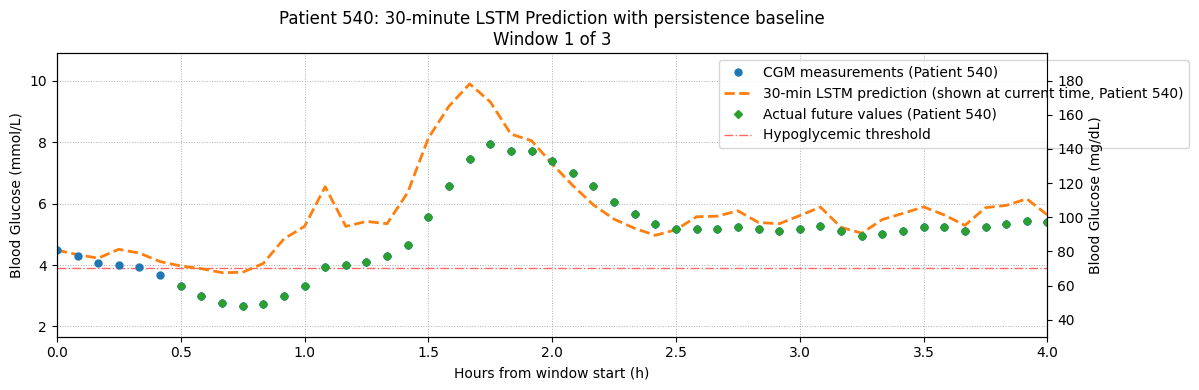

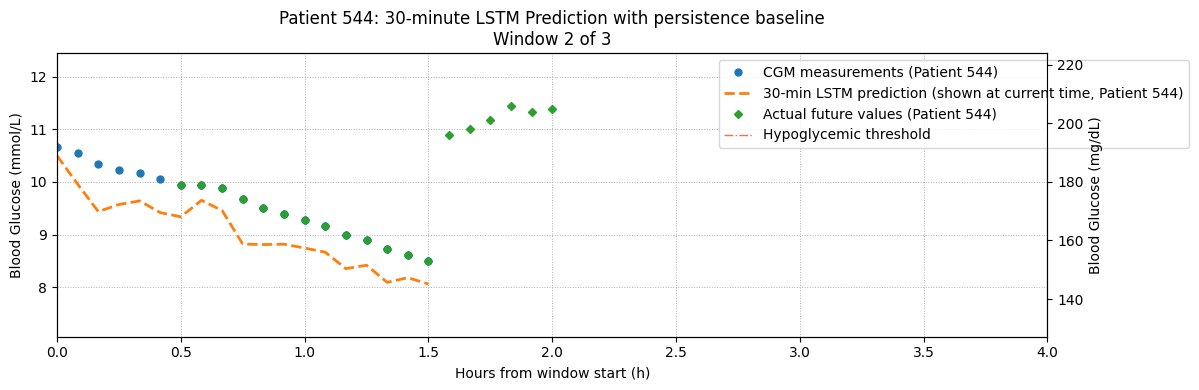

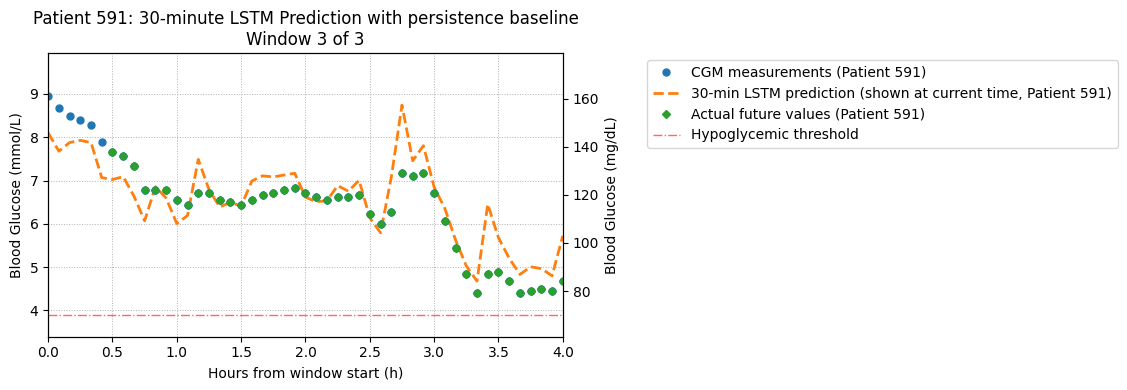

-- Plots WITH persistence baseline (predictions shown at current time) --


In [12]:
# LSTM prediction model for OhioT1DM (based on provided persistence baseline)
# - Produces the same type of plots as the original notebook
# - Two plotting modes: with and without the zero-order-hold (persistence) baseline
# - CHANGE: predictions are shown at the *current* time (the time of the last observed sample)
#   while the model still predicts the glucose value at PH_MIN minutes in the future.
# Requirements: tensorflow, scikit-learn, pandas, matplotlib, numpy
# Usage: adjust DATA path if needed and run the script / notebook cell

import os, random
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

random.seed(42); np.random.seed(42); tf.random.set_seed(42)

# --------------------------- User settings ---------------------------
DATA = "../data/OhioT1DM.csv"   # adjust if needed
PH_MIN = 30                    # prediction horizon in minutes (model predicts t + PH_MIN)
TRAIN_FRACT = 0.8
WINDOW_HOURS = 4               # how many hours of past history to use as LSTM input
BATCH_SIZE = 32
EPOCHS = 100
VERBOSE = 1

if not os.path.exists(DATA):
    raise FileNotFoundError(f"File not found: {DATA}")

# --------------------------- Load & basic cleaning ---------------------------
df = pd.read_csv(DATA, parse_dates=["date"]).sort_values(["id","date"]).reset_index(drop=True)
df = df.dropna(subset=["CGM"]).copy()
df["CGM"] = pd.to_numeric(df["CGM"], errors="coerce")

# compute median sampling interval (minutes) per subject -> global median
def med_int(g):
    d = g["date"].diff().dt.total_seconds().dropna()/60.0
    return d.median() if len(d)>0 else np.nan
median_interval = df.groupby("id").apply(med_int).dropna().median()
if np.isnan(median_interval): raise RuntimeError("Cannot infer sampling interval.")
steps = max(1, int(round(PH_MIN/median_interval)))
window_steps = max(1, int(round(WINDOW_HOURS*60/median_interval)))
print(f"median sampling interval = {median_interval:.2f} min -> steps={steps}, window_steps={window_steps}")

# --------------------------- Build supervised windows for LSTM ---------------------------
# We'll build sequences of length `window_steps` that end at time t (last observation in seq),
# and the target is the CGM at t + PH_MIN (i.e., the value `steps` indices ahead)
rows = []
for sid, g in df.groupby("id"):
    g = g.reset_index(drop=True)
    if len(g) <= steps: continue
    for i in range(len(g) - steps):
        # require a full window of past samples
        if i - window_steps + 1 < 0:
            continue
        seq = g["CGM"].iloc[i - window_steps + 1: i+1].values.astype(float)
        target = g["CGM"].iloc[i + steps]
        last_date = g["date"].iloc[i]
        pred_time = last_date + pd.Timedelta(minutes=PH_MIN)
        rows.append({
            "id": sid,
            "date": last_date,
            "pred_time": pred_time,
            "seq": seq,
            "last_cgm": seq[-1],
            "target_CGM": float(target)
        })

data = pd.DataFrame(rows)
if data.empty: raise RuntimeError("No supervised samples found.")
print(f"Total supervised samples: {len(data)}")

# --------------------------- Subject-level split (no leakage) ---------------------------
subjects = sorted(data["id"].unique()); random.shuffle(subjects)
ntrain = int(len(subjects)*TRAIN_FRACT)
train_s = set(subjects[:ntrain]); test_s = set(subjects[ntrain:])
train_df = data[data["id"].isin(train_s)].reset_index(drop=True)
test_df  = data[data["id"].isin(test_s)].reset_index(drop=True)
print(f"subjects total/train/test = {len(subjects)}/{len(train_s)}/{len(test_s)}")
print(f"samples train/test = {len(train_df)}/{len(test_df)}  (steps={steps})")

# --------------------------- Scaling ---------------------------
# Fit a MinMax scaler on TRAIN values (both sequences and targets) to keep scale [0,1]
scaler = MinMaxScaler(feature_range=(0,1))
# concatenate all sequence values from train to fit
train_values = np.concatenate(train_df['seq'].values).reshape(-1,1)
scaler.fit(train_values)

# helper to transform sequences and targets
def transform_seq_array(seq_list, scaler):
    X = np.stack([scaler.transform(s.reshape(-1,1)).reshape(-1) for s in seq_list])
    return X[..., np.newaxis]  # shape (n, seq_len, 1)

X_train = transform_seq_array(train_df['seq'].values, scaler)
y_train = scaler.transform(train_df[['target_CGM']].values).reshape(-1)
X_test  = transform_seq_array(test_df['seq'].values, scaler)
y_test  = scaler.transform(test_df[['target_CGM']].values).reshape(-1)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

# --------------------------- Build LSTM model ---------------------------
seq_len = X_train.shape[1]
model = Sequential([
    LSTM(64, input_shape=(seq_len,1)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

history = model.fit(X_train, y_train, validation_split=0.1, epochs=EPOCHS,
                    batch_size=BATCH_SIZE, callbacks=[es], verbose=VERBOSE)

# --------------------------- Evaluate on test set ---------------------------
y_pred_scaled = model.predict(X_test).reshape(-1)
# invert scaling
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1,1)).reshape(-1)
y_true = scaler.inverse_transform(y_test.reshape(-1,1)).reshape(-1)

rmse_mgdl = np.sqrt(mean_squared_error(y_true, y_pred))
mae_mgdl  = mean_absolute_error(y_true, y_pred)
print(f"LSTM Test RMSE = {rmse_mgdl:.2f} mg/dL, MAE = {mae_mgdl:.2f} mg/dL")

# Persistence baseline for comparison (zero-order hold: last observed CGM)
y_persist = test_df['last_cgm'].values
rmse_p = np.sqrt(mean_squared_error(y_true, y_persist))
mae_p  = mean_absolute_error(y_true, y_persist)
print(f"Persistence baseline Test RMSE = {rmse_p:.2f} mg/dL, MAE = {mae_p:.2f} mg/dL")

# attach predictions to test_df for plotting
test_df = test_df.copy()
test_df['pred_lstm'] = y_pred
test_df['pred_persistence'] = y_persist

# Convert to mmol/L for plotting (1 mmol/L = 18 mg/dL)
test_df['target_mmol'] = test_df['target_CGM']/18.0
# We'll display the model's predicted future glucose value at the *current* time ('date')
test_df['pred_lstm_mmol'] = test_df['pred_lstm']/18.0
test_df['pred_persistence_mmol'] = test_df['pred_persistence']/18.0
# for 'actual' measurement points we will also mark last observation (the one used by model)
test_df['actual_mmol'] = test_df['last_cgm']/18.0

# --------------------------- Plotting routine (PREDICTIONS SHOWN AT CURRENT TIME) ---------------------------
hyp_mmol = 70.0/18.0

def plot_windows(test_df, with_baseline=True, max_windows=3, window_hours=WINDOW_HOURS):
    """
    Plot windows where:
      - actual measurements are shown at their original times (win['date'])
      - model predictions (and optional persistence baseline) are plotted at the *current* time (win['date'])
        because these are the values available to the clinician/user at time t (they represent the expected
        glucose at t + PH_MIN, but the prediction is made at time t).
      - the actual future values (ground truth at t + PH_MIN) are shown at win['pred_time'] (as diamonds).
    """
    test_subjects = list(test_df['id'].unique())[:6]
    count = 0
    for sid in test_subjects:
        if count >= max_windows: break
        sub = test_df[test_df['id']==sid].sort_values('date').reset_index(drop=True)
        if len(sub) < 5: continue
        start = sub['date'].iloc[0]
        mask = ((sub['date'] - start).dt.total_seconds() <= window_hours*3600) | \
               ((sub['pred_time'] - start).dt.total_seconds() <= window_hours*3600)
        win = sub.loc[mask].copy()
        if win.empty: continue

        x_actual = (win['date'] - start).dt.total_seconds()/3600.0    # time axis for measurements & predictions
        x_pred   = (win['pred_time'] - start).dt.total_seconds()/3600.0  # time axis for future ground-truth

        fig, ax1 = plt.subplots(figsize=(12,4))

        # Plot CGM measurements (current-time dots)
        l1 = ax1.plot(x_actual, win['actual_mmol'], 'o', markersize=5, label=f"CGM measurements (Patient {sid})", zorder=4)

        # Plot LSTM predictions AT current time (same x as actual measurements)
        order_actual = np.argsort(x_actual)
        l2 = ax1.plot(x_actual.values[order_actual], win['pred_lstm_mmol'].values[order_actual], linestyle='--', linewidth=2,
                      label=f"{PH_MIN}-min LSTM prediction (shown at current time, Patient {sid})", zorder=3)

        # Plot the actual future values at their future time (diamonds)
        l3 = ax1.plot(x_pred, win['target_mmol'], 'D', markersize=4, label=f"Actual future values (Patient {sid})", zorder=5)

        # optional persistence baseline shown at current time (same x as measurements)
        #if with_baseline:
        #    l4 = ax1.plot(x_actual.values[order_actual], win['pred_persistence_mmol'].values[order_actual], linestyle=':', linewidth=2,
        #                  label=f"{PH_MIN}-min persistence baseline (shown at current time, Patient {sid})", zorder=2)

        # adjust y limits to include all series
        ymin = max(0, min(win['actual_mmol'].min(), win['pred_lstm_mmol'].min(), win['target_mmol'].min()) - 1)
        ymax = max(win['actual_mmol'].max(), win['pred_lstm_mmol'].max(), win['target_mmol'].max()) + 1
        ax1.set_xlim(0, window_hours)
        ax1.set_ylim(ymin, ymax)
        ax1.set_xlabel("Hours from window start (h)")
        ax1.set_ylabel("Blood Glucose (mmol/L)")
        ax1.grid(linestyle=':', linewidth=0.7)

        # Second axis in mg/dL
        ax2 = ax1.twinx()
        ax2.set_ylim(ax1.get_ylim()[0]*18, ax1.get_ylim()[1]*18)
        ax2.set_ylabel("Blood Glucose (mg/dL)")

        l5 = ax1.axhline(hyp_mmol, linestyle='-.', linewidth=1, alpha=0.6, color='red', label='Hypoglycemic threshold')

        # combine legend
        # ax.plot returns a list of Line2D objects; ensure we flatten them into a single list
        lines = []
        lines.extend(l1)   # l1 is a list
        lines.extend(l2)
        lines.extend(l3)
        #if with_baseline:
        #    lines.extend(l4)
        lines.append(l5)   # l5 is a single Line2D
        labels = [ln.get_label() for ln in lines]
        ax1.legend(lines, labels, bbox_to_anchor=(1.15,1))

        plt.title(f"Patient {sid}: {PH_MIN}-minute LSTM Prediction {'with' if with_baseline else 'without'} persistence baseline\nWindow {count+1} of {max_windows}")
        plt.tight_layout()
        plt.show()
        count += 1

# --------------------------- Show plots ---------------------------
print('-- Plots WITHOUT persistence baseline (predictions shown at current time) --')
plot_windows(test_df) #, with_baseline=False)
print('-- Plots WITH persistence baseline (predictions shown at current time) --')
#plot_windows(test_df, with_baseline=True)

# --------------------------- End of script ---------------------------

# Explanation for the change:
# - The LSTM model still *learns* to predict the glucose value at t + PH_MIN (i.e. 30 minutes ahead).
# - In real-time use you make that prediction at time t (when the last measurement arrived). Showing the
#   predicted value at the *current* time (t) makes the plots reflect what a clinician/user would see right now
#   (the numeric prediction represents a future glucose value, but the point is available now).
# - If instead you want the model to predict the *current* glucose (i.e. reconstruct/smooth the present value),
#   then you would set target_CGM = CGM at time t and retrain; that's a different modeling goal.

# If you'd like, I can also:
# - change the model to explicitly predict the value at the current time (reconstruction), or
# - provide deployment-style plots that show how predictions would be used in a live streaming setting.
# Tell me which one and I'll update the canvas content accordingly.


In [13]:
!pip install error-grids

Clarke Error Grid (LSTM): A: 36.4%, B: 48.1%, C: 0.0%, D: 15.5%, E: 0.0%
Clarke Error Grid (Persistence baseline): A: 64.9%, B: 30.8%, C: 0.8%, D: 3.2%, E: 0.3%

Formatted (A-E) LSTM: ['36.4%', '48.1%', '0.0%', '15.5%', '0.0%']
Formatted (A-E) Persistence: ['64.9%', '30.8%', '0.8%', '3.2%', '0.3%']


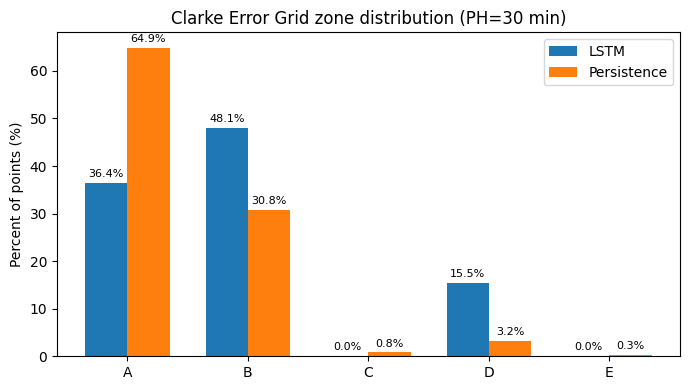


ClarkeMetric.calculate() -> {'A': '36.4%', 'B': '48.1%', 'C': '0.0%', 'D': '15.5%', 'E': '0.0%'}


In [28]:
# --------------------------- Clarke Error Grid evaluation (inserted) ---------------------------
import warnings
import matplotlib.pyplot as plt
from collections import OrderedDict

# try to import the canonical zone_accuracy routine from the error_grids package
_use_error_grids = True
try:
    from error_grids import zone_accuracy
except Exception as e:
    warnings.warn("Package 'error_grids' not available. Using approximate fallback Clarke grid implementation. "
                  "Install the package with `pip install error-grids` for the canonical implementation.\n"
                  f"Import error: {e}")
    _use_error_grids = False

def _format_pct_list(zone_list):
    return ["{:.1f}%".format(v * 100) for v in zone_list]

def clarke_zone_fallback(y_true, y_pred):
    """
    Conservative fallback approximate Clarke Error Grid zoning.
    This is NOT a perfect replacement for the canonical algorithm but gives reasonable zone-A/B splits:
      - Zone A: within ±20% of reference when reference >= 70 mg/dL; if reference < 70, predicted < 70 -> A
      - Zone B: not in A but would not lead to wrong treatment (approx)
      - Zones C/D/E: rough assignment for large errors
    Returns fractions [A,B,C,D,E].
    """
    if len(y_true) != len(y_pred):
        raise ValueError("y_true and y_pred must have same length")
    counts = OrderedDict(A=0, B=0, C=0, D=0, E=0)
    for r, p in zip(y_true, y_pred):
        # handle NaNs
        if np.isnan(r) or np.isnan(p):
            continue
        # zone A rules (classic simplified)
        if r >= 70:
            if abs(p - r) <= 0.2 * r:
                counts['A'] += 1
                continue
        else:  # r < 70
            # if both predicted and reference are hypoglycemic -> clinically acceptable
            if p < 70:
                counts['A'] += 1
                continue
            # allow a small absolute tolerance as well
            if abs(p - r) <= 12:  # 12 mg/dL tolerance for low BG
                counts['A'] += 1
                continue

        # zone B (approx): prediction outside ±20% but not extremely wrong
        # we'll assign B if the prediction moves in same treatment direction and is within a
        # moderate factor (not crossing strong risk boundaries); heuristics follow.
        if r >= 70:
            # if predicted and reference are both above 70 and prediction isn't wildly off -> B
            if p >= 70 and (abs(p - r) <= 0.5 * r):
                counts['B'] += 1
                continue
            # if prediction below 70 but not extremely low -> B
            if p < 70 and p >= 54:  # 54 mg/dL lower-border moderate
                counts['B'] += 1
                continue
        else:
            # r < 70 but prediction slightly above 70 (small miss) -> B
            if p >= 70 and p <= 110:
                counts['B'] += 1
                continue

        # zone E (dangerous opposite-direction large error): approximation:
        # if r < 70 (hypo) but prediction very high (>180) or r > 180 but predicted very low (<70)
        if (r < 70 and p > 180) or (r > 180 and p < 70):
            counts['E'] += 1
            continue

        # zone D: large error that would lead to dangerous failure to detect hypo/hyper
        if (r < 70 and p >= 110) or (r > 240 and p <= 140):
            counts['D'] += 1
            continue

        # remaining significant errors go to C
        counts['C'] += 1

    total = float(sum(counts.values()))
    if total == 0:
        return [0, 0, 0, 0, 0]
    return [counts[k] / total for k in counts.keys()]

def compute_clarke(y_true, y_pred, label="Model"):
    """
    Compute Clarke Error Grid zone fractions for y_true and y_pred (both mg/dL arrays).
    Returns tuple (zone_names, fractions_list).
    """
    if _use_error_grids:
        # error_grids.zone_accuracy expects arrays, returns list for zones A..E
        try:
            zones = zone_accuracy(y_true, y_pred, 'clarke')  # expected order A,B,C,D,E as fractions
        except Exception as e:
            warnings.warn(f"error_grids.zone_accuracy failed: {e}. Falling back to approximate.")
            zones = clarke_zone_fallback(y_true, y_pred)
    else:
        zones = clarke_zone_fallback(y_true, y_pred)
    names = ['A', 'B', 'C', 'D', 'E']
    return names, zones

def print_clarke_summary(names, fractions, label):
    s = ", ".join([f"{n}: {f*100:.1f}%" for n, f in zip(names, fractions)])
    print(f"Clarke Error Grid ({label}): {s}")

# compute for LSTM and persistence baseline (we have y_true, y_pred, y_persist from above)
# Ensure arrays are numpy arrays of mg/dL values
y_true_arr = np.asarray(y_true).reshape(-1)
y_pred_arr = np.asarray(y_pred).reshape(-1)
y_persist_arr = np.asarray(y_persist).reshape(-1)

# remove NaN pairs if any
mask_valid = (~np.isnan(y_true_arr)) & (~np.isnan(y_pred_arr))
y_true_clean = y_true_arr[mask_valid]
y_pred_clean = y_pred_arr[mask_valid]
# for persistence baseline keep same mask (should align)
y_persist_clean = y_persist_arr[mask_valid]

# Evaluate LSTM
names_l, fractions_l = compute_clarke(y_true_clean, y_pred_clean, label="LSTM")
print_clarke_summary(names_l, fractions_l, "LSTM")

# Evaluate persistence baseline
names_p, fractions_p = compute_clarke(y_true_clean, y_persist_clean, label="Persistence")
print_clarke_summary(names_p, fractions_p, "Persistence baseline")

# formatted output for integration with Metric class style if needed
formatted_l = _format_pct_list(fractions_l)
formatted_p = _format_pct_list(fractions_p)

print("\nFormatted (A-E) LSTM:", formatted_l)
print("Formatted (A-E) Persistence:", formatted_p)

# Optional: bar plot comparing LSTM vs persistence across zones
fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(len(names_l))
width = 0.35
ax.bar(x - width/2, np.array(fractions_l) * 100, width, label='LSTM')
ax.bar(x + width/2, np.array(fractions_p) * 100, width, label='Persistence')
ax.set_xticks(x)
ax.set_xticklabels(names_l)
ax.set_ylabel('Percent of points (%)')
ax.set_title(f'Clarke Error Grid zone distribution (PH={PH_MIN} min)')
ax.legend()
for i, v in enumerate(np.array(fractions_l) * 100):
    ax.text(i - width/2, v + 0.8, f"{v:.1f}%", ha='center', va='bottom', fontsize=8)
for i, v in enumerate(np.array(fractions_p) * 100):
    ax.text(i + width/2, v + 0.8, f"{v:.1f}%", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


# --------------------------- Optional: wrap in a Metric class (if you want to reuse) --------------
# The user-provided snippet assumed a BaseMetric. If you have that base, you can replace the implementation below.
try:
    from .base_metric import BaseMetric
    class ClarkeMetric(BaseMetric):
        def __init__(self):
            super().__init__('Clarke Error Grid')

        def _calculate_metric(self, y_true, y_pred, *args, **kwargs):
            names, fractions = compute_clarke(np.asarray(y_true).reshape(-1), np.asarray(y_pred).reshape(-1))
            return {n: f for n, f in zip(names, fractions)}
except Exception:
    # no BaseMetric available - provide a minimal class for local use
    class ClarkeMetric:
        def __init__(self):
            self.name = 'Clarke Error Grid (approx)'

        def calculate(self, y_true, y_pred):
            names, fractions = compute_clarke(np.asarray(y_true).reshape(-1), np.asarray(y_pred).reshape(-1))
            return {n: f for n, f in zip(names, fractions)}

# Example usage of the simple class:
cm = ClarkeMetric()
if hasattr(cm, 'calculate'):
    result = cm.calculate(y_true_clean, y_pred_clean)
else:
    # BaseMetric variant may require internal API; ignore here
    result = None
# print result from simple wrapper (if any)
if result is not None:
    print("\nClarkeMetric.calculate() ->", {k: f"{v*100:.1f}%" for k,v in result.items()})


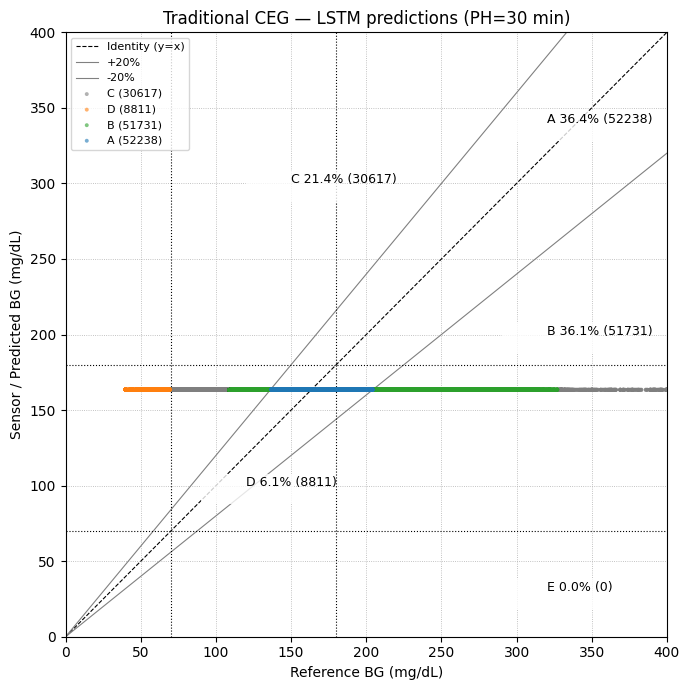

Clarke zone counts (A-E): {'A': 52238, 'B': 51731, 'C': 30617, 'D': 8811, 'E': 0}
Clarke zone percentages (A-E): {'A': '36.4%', 'B': '36.1%', 'C': '21.4%', 'D': '6.1%', 'E': '0.0%'}


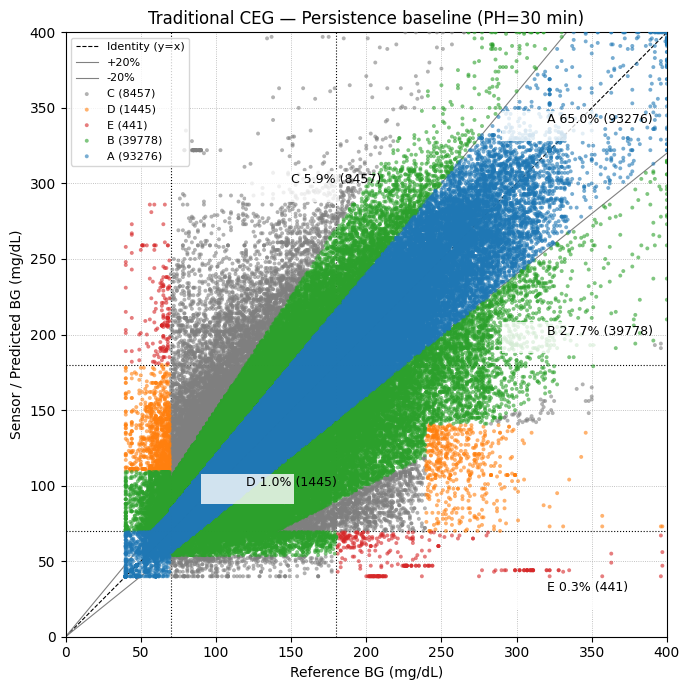

Clarke zone counts (A-E): {'A': 93276, 'B': 39778, 'C': 8457, 'D': 1445, 'E': 441}
Clarke zone percentages (A-E): {'A': '65.0%', 'B': '27.7%', 'C': '5.9%', 'D': '1.0%', 'E': '0.3%'}


In [29]:
# --------------------------- Traditional Clarke Error Grid plots ---------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import Counter

# Simple deterministic classifier (approximate Clarke zones; consistent with the earlier fallback)
def classify_clarke_point(r, s):
    """
    r: reference (mg/dL)
    s: sensor/prediction (mg/dL)
    returns: zone letter 'A'..'E'
    """
    if np.isnan(r) or np.isnan(s):
        return None

    # Zone A rules
    if r >= 70:
        if abs(s - r) <= 0.2 * r:
            return 'A'
    else:  # r < 70
        # Both hypo -> acceptable (A)
        if s < 70:
            return 'A'
        # small absolute difference at low values
        if abs(s - r) <= 12:
            return 'A'

    # Zone E (dangerous opposite-direction large error)
    if (r < 70 and s > 180) or (r > 180 and s < 70):
        return 'E'

    # Zone D (failure to detect hypo/hyper)
    if (r < 70 and s >= 110) or (r > 240 and s <= 140):
        return 'D'

    # Zone B: not A, but clinically acceptable (less severe)
    # Heuristics: same side of 70/180 boundaries and moderately off
    if r >= 70:
        if s >= 70 and (abs(s - r) <= 0.5 * r):
            return 'B'
        if s < 70 and s >= 54:
            return 'B'
    else:
        if s >= 70 and s <= 110:
            return 'B'

    # Remaining significant errors -> C
    return 'C'

def clarke_zones_array(y_ref, y_pred):
    zones = [classify_clarke_point(r, p) for r, p in zip(y_ref, y_pred)]
    return np.array(zones)

def plot_clarke_grid(y_ref, y_pred, title="Traditional CEG", vmin=0, vmax=400, show_percent=True):
    """
    Draw a Clarke Error Grid-style plot.
    y_ref, y_pred : arrays (mg/dL)
    """
    # make arrays
    y_ref = np.asarray(y_ref).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    # valid mask
    mask = (~np.isnan(y_ref)) & (~np.isnan(y_pred))
    y_ref = y_ref[mask]
    y_pred = y_pred[mask]
    if len(y_ref) == 0:
        print("No valid points to plot.")
        return

    zones = clarke_zones_array(y_ref, y_pred)
    counts = Counter(z for z in zones if z is not None)
    total = sum(counts.values())

    # colors by zone
    color_map = {'A': '#1f77b4',  # blue
                 'B': '#2ca02c',  # green
                 'C': '#7f7f7f',  # gray
                 'D': '#ff7f0e',  # orange
                 'E': '#d62728'}  # red

    # scatter per zone
    fig, ax = plt.subplots(figsize=(7,7))
    # plot background gridlines typical to CEG (identity + +/-20%)
    x = np.linspace(vmin, vmax, 500)
    ax.plot(x, x, linestyle='--', color='k', linewidth=0.8, label='Identity (y=x)')
    ax.plot(x, 1.2*x, linestyle='-', color='0.5', linewidth=0.8, label='+20%')
    ax.plot(x, 0.8*x, linestyle='-', color='0.5', linewidth=0.8, label='-20%')

    # vertical and horizontal thresholds (typical)
    ax.axvline(70, color='k', linestyle=':', linewidth=0.8)
    ax.axhline(70, color='k', linestyle=':', linewidth=0.8)
    ax.axvline(180, color='k', linestyle=':', linewidth=0.8)
    ax.axhline(180, color='k', linestyle=':', linewidth=0.8)

    # Scatter points zone by zone (zorder so A on top)
    for zone in ['C','D','E','B','A']:  # draw C/D/E first, A last
        mask_zone = zones == zone
        if mask_zone.sum() > 0:
            ax.scatter(y_ref[mask_zone], y_pred[mask_zone],
                       s=8, alpha=0.6, label=f"{zone} ({counts.get(zone,0)})",
                       color=color_map.get(zone,'k'), edgecolors='none', zorder=3)

    # axis limits and labels
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)
    ax.set_xlabel("Reference BG (mg/dL)")
    ax.set_ylabel("Sensor / Predicted BG (mg/dL)")
    ax.set_title(title)

    # annotate percentages inside the figure near rough region locations
    def pct(z): return f"{(counts.get(z,0)/total*100):.1f}%"
    # approximate positions for annotation (tweak if you like)
    ann = {
        'A': (320, 340),
        'B': (320, 200),
        'C': (150, 300),
        'D': (120, 100),
        'E': (320, 30)
    }
    for z, pos in ann.items():
        ax.add_patch(patches.Rectangle((pos[0]-30, pos[1]-12), 62, 20,
                     facecolor='white', edgecolor='none', alpha=0.8, zorder=4))
        ax.text(pos[0], pos[1], f"{z} {pct(z)} ({counts.get(z,0)})",
                fontsize=9, bbox=dict(facecolor='white', alpha=0.0), zorder=5)

    ax.grid(True, linestyle=':', linewidth=0.6)
    ax.legend(loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

    # Also print numeric summary
    print("Clarke zone counts (A-E):", {k: counts.get(k,0) for k in ['A','B','C','D','E']})
    print("Clarke zone percentages (A-E):", {k: f"{counts.get(k,0)/total*100:.1f}%" for k in ['A','B','C','D','E']})

# --------------------------- Create plots for LSTM and Persistence ---------------------------
# Use the cleaned arrays used above (y_true_clean, y_pred_clean, y_persist_clean)
# If those variables are not present in your environment, fall back to y_true, y_pred, y_persist
try:
    y_ref_plot = y_true_clean
    y_lstm_plot = y_pred_clean
    y_pers_plot = y_persist_clean
except NameError:
    # use the basic arrays from above
    y_ref_plot = y_true
    y_lstm_plot = y_pred
    y_pers_plot = y_persist

# Clip plotting range a bit for nicer visuals, but keep original arrays for classification
plot_clarke_grid(y_ref_plot, y_lstm_plot, title=f"Traditional CEG — LSTM predictions (PH={PH_MIN} min)")
plot_clarke_grid(y_ref_plot, y_pers_plot, title=f"Traditional CEG — Persistence baseline (PH={PH_MIN} min)")


Parkes/Consensus Error Grid (LSTM): A: 34.5%, B: 47.4%, C: 13.6%, D: 4.5%, E: 0.0%
Parkes/Consensus Error Grid (Persistence baseline): A: 68.3%, B: 27.8%, C: 3.4%, D: 0.4%, E: 0.0%

Formatted (A-E) LSTM (Parkes): ['34.5%', '47.4%', '13.6%', '4.5%', '0.0%']
Formatted (A-E) Persistence (Parkes): ['68.3%', '27.8%', '3.4%', '0.4%', '0.0%']


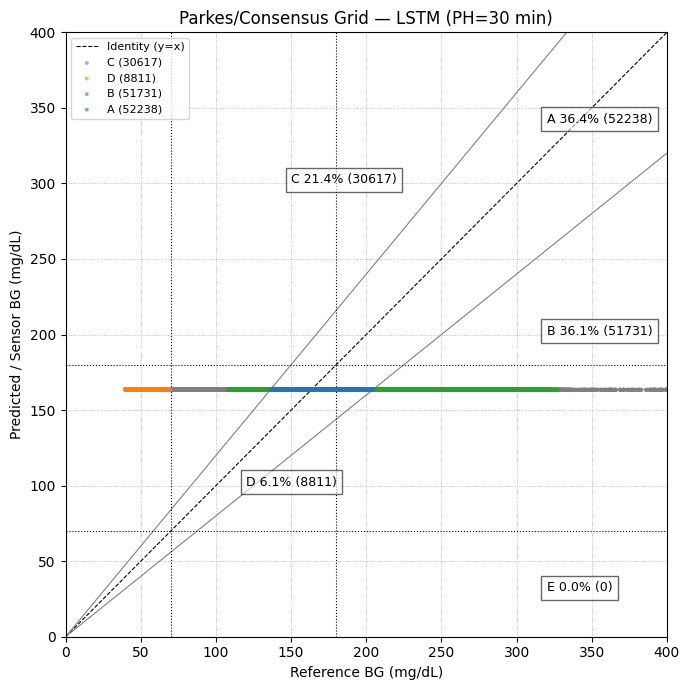

Parkes zone counts (A-E): {'A': 52238, 'B': 51731, 'C': 30617, 'D': 8811, 'E': 0}
Parkes zone percentages (A-E): {'A': '36.4%', 'B': '36.1%', 'C': '21.4%', 'D': '6.1%', 'E': '0.0%'}


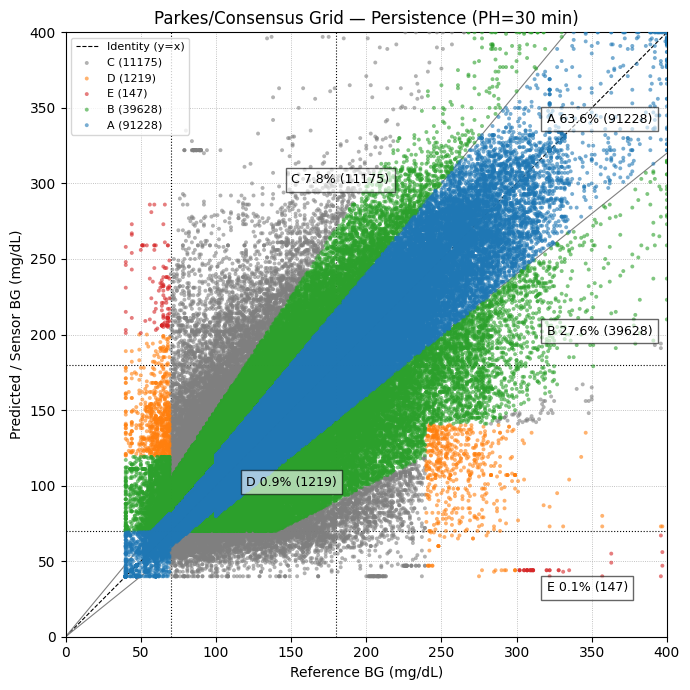

Parkes zone counts (A-E): {'A': 91228, 'B': 39628, 'C': 11175, 'D': 1219, 'E': 147}
Parkes zone percentages (A-E): {'A': '63.6%', 'B': '27.6%', 'C': '7.8%', 'D': '0.9%', 'E': '0.1%'}

ParkesMetric.calculate (sample): {'A': '34.5%', 'B': '47.4%', 'C': '13.6%', 'D': '4.5%', 'E': '0.0%'}


In [30]:
# --------------------------- Parkes (Consensus) Error Grid evaluation + plots ---------------------------
import warnings
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, OrderedDict

# Try canonical zone_accuracy with Parkes/Consensus option (many packages call it 'parkes' or 'consensus')
_use_error_grids_for_parkes = True
_zone_accuracy_func = None
try:
    from error_grids import zone_accuracy
    # test which identifier works
    for key in ('parkes', 'consensus', 'parkes_consensus', 'parkes_adult', 'parkes_t1'):
        try:
            # run a tiny sanity check with two points (this won't be used)
            zone_accuracy(np.array([100.0]), np.array([100.0]), key)
            _zone_accuracy_func = lambda y_true, y_pred: zone_accuracy(y_true, y_pred, key)
            break
        except Exception:
            _zone_accuracy_func = None
    if _zone_accuracy_func is None:
        warnings.warn("error_grids imported but no recognized Parkes identifier worked. Will use fallback classifier.")
except Exception as e:
    warnings.warn(f"Package 'error_grids' not available or import failed ({e}); using fallback Parkes classifier.")
    _use_error_grids_for_parkes = False
    _zone_accuracy_func = None

# ------------------ Fallback Parkes classifier (heuristic approximation) ------------------
def classify_parkes_point(r, s):
    """
    Heuristic Parkes/Consensus classifier (approximate).
    r: reference mg/dL, s: sensor/predicted mg/dL
    returns zone 'A'..'E'
    NOTE: This is an approximation for quick visualization when canonical package isn't installed.
    """
    if np.isnan(r) or np.isnan(s):
        return None

    # zone A: clinically accurate - small relative error in typical range, or both correctly hypoglycemic/hyperglycemic
    if r >= 100:
        if abs(s - r) <= 0.2 * r:  # within ±20% for mid-high range
            return 'A'
    elif r >= 70:
        if abs(s - r) <= 0.15 * r:  # slightly stricter in this mid range
            return 'A'
    else:
        # for low references, consider predictions that also indicate low (clinically similar) as A
        if s < 70 or abs(s - r) <= 12:
            return 'A'

    # zone E: highly dangerous opposite-direction large error (approx)
    if (r < 70 and s > 200) or (r > 300 and s < 70):
        return 'E'

    # zone D: large clinically significant errors (missed hypo/hyper)
    if (r < 70 and s >= 120) or (r > 240 and s <= 140):
        return 'D'

    # zone B: not A but clinically acceptable (less severe)
    # moderate relative error or same clinical side
    if (r >= 70 and s >= 70 and abs(s - r) <= 0.5 * r) or (r < 70 and s >= 70 and s <= 140):
        return 'B'

    # Remaining significant errors -> C
    return 'C'

def parkes_zones_array(y_ref, y_pred):
    return np.array([classify_parkes_point(r, p) for r, p in zip(y_ref, y_pred)])

# ------------------ Compute zone fractions (using canonical if available) ------------------
def compute_parkes_fractions(y_true_mg, y_pred_mg):
    """
    Returns (names, fractions) for Parkes zones A..E.
    If canonical zone_accuracy is available we'll use it; else fallback to heuristic counting.
    """
    y_true_mg = np.asarray(y_true_mg).reshape(-1)
    y_pred_mg = np.asarray(y_pred_mg).reshape(-1)
    mask = (~np.isnan(y_true_mg)) & (~np.isnan(y_pred_mg))
    y_true_mg = y_true_mg[mask]; y_pred_mg = y_pred_mg[mask]
    if len(y_true_mg) == 0:
        return ['A','B','C','D','E'], [0,0,0,0,0]

    if _zone_accuracy_func is not None:
        try:
            fractions = _zone_accuracy_func(y_true_mg, y_pred_mg)
            # zone_accuracy typically returns [A,B,C,D,E] fractions; ensure length 5
            if hasattr(fractions, '__len__') and len(fractions) == 5:
                return ['A','B','C','D','E'], list(fractions)
        except Exception as e:
            warnings.warn(f"Canonical parkes zone_accuracy failed: {e}; falling back to heuristic classifier.")

    # fallback counting
    zones = parkes_zones_array(y_true_mg, y_pred_mg)
    counts = OrderedDict(A=0, B=0, C=0, D=0, E=0)
    for z in zones:
        if z in counts:
            counts[z] += 1
    total = float(sum(counts.values()))
    if total == 0:
        return list(counts.keys()), [0]*5
    return list(counts.keys()), [counts[k]/total for k in counts.keys()]

def print_parkes_summary(names, fractions, label):
    s = ", ".join([f"{n}: {f*100:.1f}%" for n, f in zip(names, fractions)])
    print(f"Parkes/Consensus Error Grid ({label}): {s}")

# ------------------ Compute for LSTM and Persistence ------------------
# Use cleaned arrays if available, else fallback to y_true/y_pred/y_persist
try:
    y_ref_arr = np.asarray(y_true_clean).reshape(-1)
    y_lstm_arr = np.asarray(y_pred_clean).reshape(-1)
    y_pers_arr = np.asarray(y_persist_clean).reshape(-1)
except NameError:
    y_ref_arr = np.asarray(y_true).reshape(-1)
    y_lstm_arr = np.asarray(y_pred).reshape(-1)
    y_pers_arr = np.asarray(y_persist).reshape(-1)

names_l, fracs_l = compute_parkes_fractions(y_ref_arr, y_lstm_arr)
names_p, fracs_p = compute_parkes_fractions(y_ref_arr, y_pers_arr)



print_parkes_summary(names_l, fracs_l, "LSTM")
print_parkes_summary(names_p, fracs_p, "Persistence baseline")

# formatted lists (for consistency with previous Metric format)
formatted_l_parkes = ["{:.1f}%".format(v*100) for v in fracs_l]
formatted_p_parkes = ["{:.1f}%".format(v*100) for v in fracs_p]
print("\nFormatted (A-E) LSTM (Parkes):", formatted_l_parkes)
print("Formatted (A-E) Persistence (Parkes):", formatted_p_parkes)

# ------------------ Parkes-style scatter plot (colored by zone) ------------------
def plot_parkes_grid(y_ref, y_pred, title="Parkes / Consensus Error Grid", vmin=0, vmax=400):
    y_ref = np.asarray(y_ref).reshape(-1); y_pred = np.asarray(y_pred).reshape(-1)
    mask = (~np.isnan(y_ref)) & (~np.isnan(y_pred))
    y_ref = y_ref[mask]; y_pred = y_pred[mask]
    if y_ref.size == 0:
        print("No valid points to plot for Parkes grid.")
        return

    zones = parkes_zones_array(y_ref, y_pred)
    counts = Counter(z for z in zones if z is not None)
    total = sum(counts.values())

    color_map = {'A': '#1f77b4',  # blue
                 'B': '#2ca02c',  # green
                 'C': '#7f7f7f',  # gray
                 'D': '#ff7f0e',  # orange
                 'E': '#d62728'}  # red

    fig, ax = plt.subplots(figsize=(7,7))
    x = np.linspace(vmin, vmax, 500)
    ax.plot(x, x, linestyle='--', color='k', linewidth=0.8, label='Identity (y=x)')
    # plot ±20% as guides (Parkes has different shapes, but these help visual comparison)
    ax.plot(x, 1.2*x, linestyle='-', color='0.5', linewidth=0.8)
    ax.plot(x, 0.8*x, linestyle='-', color='0.5', linewidth=0.8)

    # typical clinical threshold lines
    ax.axvline(70, color='k', linestyle=':', linewidth=0.8)
    ax.axhline(70, color='k', linestyle=':', linewidth=0.8)
    ax.axvline(180, color='k', linestyle=':', linewidth=0.8)
    ax.axhline(180, color='k', linestyle=':', linewidth=0.8)

    # scatter for zones (draw less-critical zones first so A on top)
    for zone in ['C','D','E','B','A']:
        mask_zone = zones == zone
        if mask_zone.sum() > 0:
            ax.scatter(y_ref[mask_zone], y_pred[mask_zone],
                       s=8, alpha=0.6, label=f"{zone} ({counts.get(zone,0)})",
                       color=color_map.get(zone,'k'), edgecolors='none', zorder=3)

    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)
    ax.set_xlabel("Reference BG (mg/dL)")
    ax.set_ylabel("Predicted / Sensor BG (mg/dL)")
    ax.set_title(title)
    ax.grid(True, linestyle=':', linewidth=0.6)
    ax.legend(loc='upper left', fontsize=8)

    # annotate approximate percentages
    def pct(z): return f"{(counts.get(z,0)/total*100):.1f}%"
    ann = {
        'A': (320, 340),
        'B': (320, 200),
        'C': (150, 300),
        'D': (120, 100),
        'E': (320, 30)
    }
    for z, pos in ann.items():
        ax.text(pos[0], pos[1], f"{z} {pct(z)} ({counts.get(z,0)})",
                fontsize=9, bbox=dict(facecolor='white', alpha=0.6), zorder=5)

    plt.tight_layout()
    plt.show()

    # textual summary
    print("Parkes zone counts (A-E):", {k: counts.get(k,0) for k in ['A','B','C','D','E']})
    print("Parkes zone percentages (A-E):", {k: f"{counts.get(k,0)/total*100:.1f}%" for k in ['A','B','C','D','E']})

# ------------------ Generate plots ------------------
plot_parkes_grid(y_ref_arr, y_lstm_arr, title=f"Parkes/Consensus Grid — LSTM (PH={PH_MIN} min)")
plot_parkes_grid(y_ref_arr, y_pers_arr, title=f"Parkes/Consensus Grid — Persistence (PH={PH_MIN} min)")

# ------------------ Optional Parkes Metric wrapper ------------------
try:
    from .base_metric import BaseMetric
    class ParkesMetric(BaseMetric):
        def __init__(self):
            super().__init__('Parkes Error Grid')

        def _calculate_metric(self, y_true, y_pred, *args, **kwargs):
            names, fracs = compute_parkes_fractions(np.asarray(y_true).reshape(-1), np.asarray(y_pred).reshape(-1))
            formatted = ["{:.1f}%".format(v*100) for v in fracs]
            return dict(zip(names, formatted))
except Exception:
    class ParkesMetric:
        def __init__(self):
            self.name = 'Parkes Error Grid (approx)'

        def calculate(self, y_true, y_pred):
            names, fracs = compute_parkes_fractions(np.asarray(y_true).reshape(-1), np.asarray(y_pred).reshape(-1))
            return dict(zip(names, fracs))

# quick example
pm = ParkesMetric()
if hasattr(pm, 'calculate'):
    print("\nParkesMetric.calculate (sample):", {k: f"{v*100:.1f}%" for k,v in pm.calculate(y_ref_arr, y_lstm_arr).items()})


In [31]:
# --------------------------- gRMSE metric (based on provided code) ---------------------------
import numpy as np

# --- Minimal fallback unit_config_manager (uses mg/dL by default) ---
class _SimpleUnitConfig:
    def __init__(self, use_mgdl=True):
        self.use_mgdl = use_mgdl

    def convert_value(self, val):
        # convert mg/dL -> mmol/L
        return val / 18.0

# If your environment already defines unit_config_manager, this will keep it.
try:
    unit_config_manager  # type: ignore
except NameError:
    unit_config_manager = _SimpleUnitConfig(use_mgdl=True)

# --- gRMSE utility functions (copied/adapted from your snippet) ---
def sigmoid(x, a, epsilon):
    xi = (2 / epsilon) * (x - a - (epsilon / 2))
    if x <= a:
        return 0.0
    elif a < x <= a + (epsilon / 2):
        return -0.5 * xi ** 4 - xi ** 3 + xi + 0.5
    elif a + (epsilon / 2) < x <= a + epsilon:
        return 0.5 * xi ** 4 - xi ** 3 + xi + 0.5
    else:  # x > a + epsilon
        return 1.0

def sigmoid_hat(x, a, epsilon):
    xi_hat = - (2 / epsilon) * (x - a + (epsilon / 2))
    if x <= a - epsilon:
        return 1.0
    elif a - epsilon < x <= a - (epsilon / 2):
        return 0.5 * xi_hat ** 4 - xi_hat ** 3 + xi_hat + 0.5
    elif a - (epsilon / 2) < x <= a:
        return -0.5 * xi_hat ** 4 - xi_hat ** 3 + xi_hat + 0.5
    else:  # a <= x
        return 0.0

def penalty(g, g_hat):
    # Constants from the table
    alpha_L = 1.5
    alpha_H = 1
    beta_L = 30
    beta_H = 100
    gamma_L = 10
    gamma_H = 20
    T_L = 85
    T_H = 155

    # Calculate the terms using the sigma functions
    sigma_T_L = sigmoid_hat(g, T_L, beta_L)
    sigma_gamma_L = sigmoid(g_hat, g, gamma_L)
    sigma_T_H = sigmoid(g, T_H, beta_H)
    sigma_gamma_H = sigmoid_hat(g_hat, g, gamma_H)

    # Final penalty calculation
    pen = (1 + alpha_L * sigma_T_L * sigma_gamma_L + alpha_H * sigma_T_H * sigma_gamma_H)
    return pen

def compute_gRMSE(y_true, y_pred):
    """
    Compute gRMSE (units: mg/dL by default). Accepts 1-D numpy arrays or lists.
    Returns numeric gRMSE (converted to mmol/L if unit_config_manager.use_mgdl == False).
    """
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    if y_true.shape != y_pred.shape:
        raise ValueError("y_true and y_pred must have same shape")

    # mask invalid values
    mask = (~np.isnan(y_true)) & (~np.isnan(y_pred))
    if mask.sum() == 0:
        return np.nan

    y_true_m = y_true[mask].astype(float)
    y_pred_m = y_pred[mask].astype(float)

    # compute penalty per point (list comprehension is fine here)
    pens = np.array([penalty(gt, gp) for gt, gp in zip(y_true_m, y_pred_m)], dtype=float)
    se   = (y_true_m - y_pred_m) ** 2
    gMSE = np.nanmean(se * pens)
    gRMSE = np.sqrt(gMSE)

    if unit_config_manager.use_mgdl:
        return float(gRMSE)
    else:
        return float(unit_config_manager.convert_value(gRMSE))

# --- Compute & print gRMSE for LSTM and persistence baseline ---
# Try to use cleaned arrays from earlier code; otherwise fall back to raw arrays
try:
    y_true_for_metric = np.asarray(y_true_clean)
    y_pred_for_metric = np.asarray(y_pred_clean)
    y_pers_for_metric  = np.asarray(y_persist_clean)
except NameError:
    y_true_for_metric = np.asarray(y_true)
    y_pred_for_metric = np.asarray(y_pred)
    y_pers_for_metric  = np.asarray(y_persist)

gRMSE_lstm = compute_gRMSE(y_true_for_metric, y_pred_for_metric)
gRMSE_pers = compute_gRMSE(y_true_for_metric, y_pers_for_metric)

unit_label = "mg/dL" if unit_config_manager.use_mgdl else "mmol/L"
print(f"gRMSE (LSTM)         = {gRMSE_lstm:.3f} {unit_label}")
print(f"gRMSE (Persistence)  = {gRMSE_pers:.3f} {unit_label}")

# --- Optional Metric wrapper compatible with your earlier style ---
try:
    from .base_metric import BaseMetric
    class Metric(BaseMetric):
        def __init__(self):
            super().__init__('gRMSE')

        def _calculate_metric(self, y_true, y_pred, *args, **kwargs):
            val = compute_gRMSE(np.asarray(y_true).reshape(-1), np.asarray(y_pred).reshape(-1))
            return val
except Exception:
    # Fallback simple wrapper
    class gRMSEMetric:
        def __init__(self):
            self.name = 'gRMSE (approx)'

        def calculate(self, y_true, y_pred):
            return compute_gRMSE(np.asarray(y_true).reshape(-1), np.asarray(y_pred).reshape(-1))

# Example: create instance and show dictionary-style result if desired
gm = gRMSEMetric()
try:
    print("\ngRMSEMetric.calculate (LSTM):", f"{gm.calculate(y_true_for_metric, y_pred_for_metric):.3f} {unit_label}")
except Exception:
    pass

# End of gRMSE block


gRMSE (LSTM)         = 80.319 mg/dL
gRMSE (Persistence)  = 47.552 mg/dL

gRMSEMetric.calculate (LSTM): 80.319 mg/dL


In [32]:
# --------------------------- Small per-subject gRMSE plot (4 random subjects) ---------------------------
import numpy as np
import matplotlib.pyplot as plt

# reproducible random pick
np.random.seed(42)

# Ensure test_df exists
try:
    test_df  # noqa: F821
except NameError:
    raise RuntimeError("test_df not found — run the model/evaluation cells first so test_df is available.")

# pick up to 4 random subjects from the test set
subject_ids = np.array(test_df['id'].unique())
if subject_ids.size == 0:
    raise RuntimeError("No subjects found in test_df.")

n_select = min(4, len(subject_ids))
selected = list(np.random.choice(subject_ids, size=n_select, replace=False))

# compute per-subject gRMSE for LSTM and persistence
lstm_vals = []
pers_vals = []
for sid in selected:
    sub = test_df[test_df['id'] == sid].sort_values('date')
    # ground truth is target_CGM (value at t+PH_MIN), preds are pred_lstm and pred_persistence (both at current time)
    y_true_sub = sub['target_CGM'].values.astype(float)
    y_lstm_sub = sub['pred_lstm'].values.astype(float)
    y_pers_sub = sub['pred_persistence'].values.astype(float)

    # compute gRMSE (uses compute_gRMSE defined earlier)
    try:
        g_l = compute_gRMSE(y_true_sub, y_lstm_sub)
        g_p = compute_gRMSE(y_true_sub, y_pers_sub)
    except Exception as e:
        # fall back to simple RMSE if compute_gRMSE missing for some reason
        from sklearn.metrics import mean_squared_error
        g_l = np.sqrt(mean_squared_error(y_true_sub[~np.isnan(y_true_sub)], y_lstm_sub[~np.isnan(y_true_sub)]))
        g_p = np.sqrt(mean_squared_error(y_true_sub[~np.isnan(y_true_sub)], y_pers_sub[~np.isnan(y_true_sub)]))

    lstm_vals.append(g_l)
    pers_vals.append(g_p)

# Bar chart: grouped bars of gRMSE per subject
x = np.arange(len(selected))
width = 0.35
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x - width/2, lstm_vals, width, label='LSTM gRMSE')
ax.bar(x + width/2, pers_vals, width, label='Persistence gRMSE')
ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in selected])
ax.set_ylabel('gRMSE (mg/dL)')
ax.set_title(f'gRMSE comparison for {len(selected)} random test subjects')
ax.legend()
for i, (lv, pv) in enumerate(zip(lstm_vals, pers_vals)):
    ax.text(i - width/2, lv + 0.5, f"{lv:.1f}", ha='center', va='bottom', fontsize=9)
    ax.text(i + width/2, pv + 0.5, f"{pv:.1f}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Time-series panels: 2x2 grid (one subplot per selected subject) showing actual future (target_CGM) at pred_time
# and predictions (LSTM & persistence) shown at 'date' (as in your plotting convention)
nplots = len(selected)
ncols = 2
nrows = int(np.ceil(nplots / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows), squeeze=False)

for idx, sid in enumerate(selected):
    r = idx // ncols
    c = idx % ncols
    ax = axes[r][c]

    sub = test_df[test_df['id'] == sid].sort_values('date').reset_index(drop=True)
    if sub.empty:
        continue

    # time axes
    start = sub['date'].iloc[0]
    x_actual = (sub['date'] - start).dt.total_seconds() / 3600.0   # hours
    x_pred_future = (sub['pred_time'] - start).dt.total_seconds() / 3600.0

    # plot actual CGM measurements (the last observed point used by model is 'actual_mmol' or last_cgm in mg/dL)
    ax.plot(x_actual, sub['last_cgm'].values, 'o-', markersize=4, label='Last observed CGM (used by model)', zorder=4)

    # plot LSTM & persistence predictions at current time (date); these predict the future target_CGM
    ax.plot(x_actual, sub['pred_lstm'].values, '--', linewidth=2, label='LSTM prediction (at current time)', zorder=3)
    #ax.plot(x_actual, sub['pred_persistence'].values, ':', linewidth=2, label='Persistence (at current time)', zorder=2)

    # plot actual future ground-truth values at pred_time (diamonds)
    #ax.plot(x_pred_future, sub['target_CGM'].values, ':', markersize=5, label=f'Actual @ t+{PH_MIN}min', zorder=5)

    # annotate gRMSE values in title
    g_l = lstm_vals[idx]
    g_p = pers_vals[idx]
    ax.set_title(f"Subject {sid} — gRMSE LSTM: {g_l:.1f}, Persistence: {g_p:.1f}")
    ax.set_xlabel('Hours from window start')
    ax.set_ylabel('Blood Glucose (mg/dL)')
    ax.grid(linestyle=':', linewidth=0.6)
    ax.legend(fontsize=8)

# hide any empty subplots
total_axes = nrows * ncols
for j in range(nplots, total_axes):
    r = j // ncols
    c = j % ncols
    axes[r][c].axis('off')

plt.tight_layout()
plt.show()


KeyError: 'target_CGM'

Glycemia detection — counts (rows=true, cols=pred):
LSTM:
 [[  194  1399     5]
 [   72 26403  1431]
 [   14  2054 10057]] 
Persistence:
 [[  712   882     4]
 [  868 24863  2175]
 [   19  2166  9940]]

Glycemia detection — percentages (row-normalized):
LSTM:
 [[12.14 87.55  0.31]
 [ 0.26 94.61  5.13]
 [ 0.12 16.94 82.94]] 
Persistence:
 [[44.56 55.19  0.25]
 [ 3.11 89.1   7.79]
 [ 0.16 17.86 81.98]]


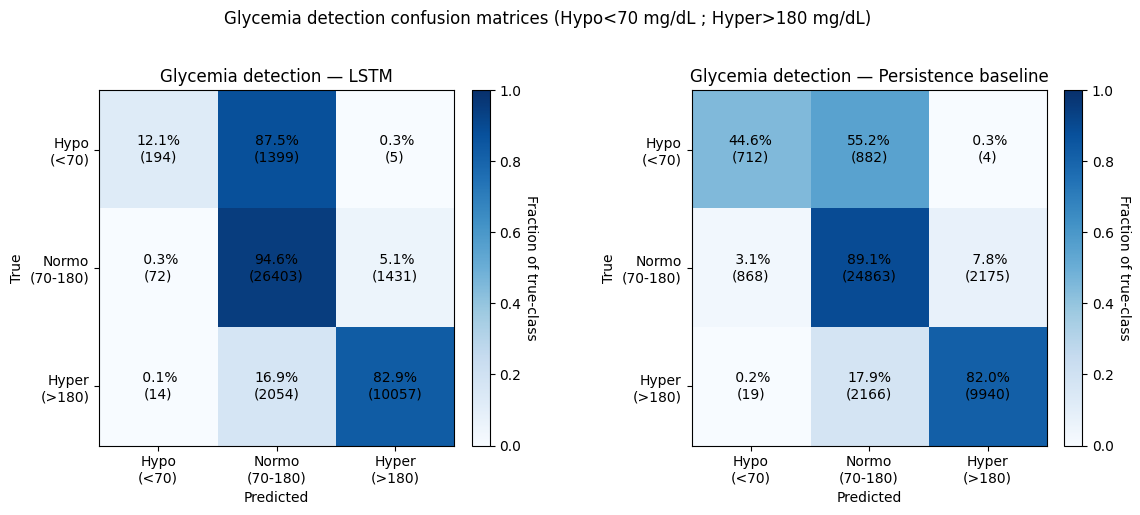


LSTM (percent + count):


,Pred_Hypo,Pred_Normo,Pred_Hyper
True_Hypo,12.1% (194),87.5% (1399),0.3% (5)
True_Normo,0.3% (72),94.6% (26403),5.1% (1431)
True_Hyper,0.1% (14),16.9% (2054),82.9% (10057)



Persistence (percent + count):


,Pred_Hypo,Pred_Normo,Pred_Hyper
True_Hypo,44.6% (712),55.2% (882),0.3% (4)
True_Normo,3.1% (868),89.1% (24863),7.8% (2175)
True_Hyper,0.2% (19),17.9% (2166),82.0% (9940)


In [ ]:
# --------------------------- Glycemia detection confusion matrices (plots) ---------------------------
import numpy as np
import matplotlib.pyplot as plt

# thresholds (mg/dL)
HYPO = 70
HYPER = 180

def glycemia_class(x, hypo=HYPO, hyper=HYPER):
    """Return 0=hypo, 1=normo, 2=hyper for scalar or array x"""
    x = np.asarray(x)
    cls = np.full(x.shape, -1, dtype=int)
    cls[x < hypo] = 0
    cls[(x >= hypo) & (x <= hyper)] = 1
    cls[x > hyper] = 2
    return cls

def compute_glycemia_confusion(y_true, y_pred, hypo=HYPO, hyper=HYPER):
    """
    y_true, y_pred: 1-D arrays (mg/dL)
    Returns:
      counts: 3x3 int array where rows=true class (0..2), cols=pred class (0..2)
      pct   : 3x3 float array where each row is normalized by the true-class count (fractions 0..1)
    """
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    # filter invalid pairs
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]; y_pred = y_pred[mask]
    n = y_true.size
    counts = np.zeros((3,3), dtype=int)
    if n == 0:
        return counts, np.full_like(counts, np.nan, dtype=float)

    true_cls = glycemia_class(y_true, hypo=hypo, hyper=hyper)
    pred_cls = glycemia_class(y_pred, hypo=hypo, hyper=hyper)

    for t, p in zip(true_cls, pred_cls):
        if 0 <= t <= 2 and 0 <= p <= 2:
            counts[t, p] += 1

    pct = np.full_like(counts, np.nan, dtype=float)
    for i in range(3):
        row_sum = counts[i].sum()
        if row_sum > 0:
            pct[i, :] = counts[i, :] / float(row_sum)
        else:
            pct[i, :] = np.nan
    return counts, pct

def plot_confusion_heatmaps(counts, pct, ax, title="", cmap='Blues'):
    """
    Annotated heatmap: shows percentages and counts in each cell.
    rows = true (Hypo,Normo,Hyper), cols = predicted
    """
    im = ax.imshow(pct, vmin=0.0, vmax=1.0, cmap=cmap, interpolation='nearest')
    ax.set_xticks(np.arange(3))
    ax.set_yticks(np.arange(3))
    labels = ['Hypo\n(<70)', 'Normo\n(70-180)', 'Hyper\n(>180)']
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)

    # annotate cells with "xx.x%\n(n)" or "NaN" if undefined
    for i in range(3):
        for j in range(3):
            c = counts[i, j]
            p = pct[i, j]
            if np.isnan(p):
                txt = "n/a\n(0)"
            else:
                txt = f"{p*100:4.1f}%\n({c})"
            ax.text(j, i, txt, ha='center', va='center', color='black', fontsize=10)

    # colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel('Fraction of true-class', rotation=270, labelpad=12)

# choose arrays (prefer cleaned ones if available)
try:
    y_true_arr = np.asarray(y_true_clean).reshape(-1)
    y_pred_arr = np.asarray(y_pred_clean).reshape(-1)
    y_pers_arr = np.asarray(y_persist_clean).reshape(-1)
except NameError:
    y_true_arr = np.asarray(y_true).reshape(-1)
    y_pred_arr = np.asarray(y_pred).reshape(-1)
    y_pers_arr = np.asarray(y_persist).reshape(-1)

# compute confusion matrices
counts_lstm, pct_lstm = compute_glycemia_confusion(y_true_arr, y_pred_arr)
counts_pers, pct_pers = compute_glycemia_confusion(y_true_arr, y_pers_arr)

# print numeric results
print("Glycemia detection — counts (rows=true, cols=pred):\nLSTM:\n", counts_lstm, "\nPersistence:\n", counts_pers)
print("\nGlycemia detection — percentages (row-normalized):\nLSTM:\n", np.round(pct_lstm * 100, 2), "\nPersistence:\n", np.round(pct_pers * 100, 2))

# plot side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_confusion_heatmaps(counts_lstm, pct_lstm, axes[0], title="Glycemia detection — LSTM")
plot_confusion_heatmaps(counts_pers, pct_pers, axes[1], title="Glycemia detection — Persistence baseline")
plt.suptitle(f"Glycemia detection confusion matrices (Hypo<{HYPO} mg/dL ; Hyper>{HYPER} mg/dL)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Additionally: a single combined table for easy glance (percentages)
import pandas as pd
def df_from_confusion(pct, counts):
    rows = ['True_Hypo', 'True_Normo', 'True_Hyper']
    cols = ['Pred_Hypo', 'Pred_Normo', 'Pred_Hyper']
    # show "xx.x% (n)"
    table = [[ (f"{(pct[i,j]*100):4.1f}% ({counts[i,j]})" if not np.isnan(pct[i,j]) else "n/a (0)")
               for j in range(3)] for i in range(3)]
    return pd.DataFrame(table, index=rows, columns=cols)

print("\nLSTM (percent + count):")
display(df_from_confusion(pct_lstm, counts_lstm))

print("\nPersistence (percent + count):")
display(df_from_confusion(pct_pers, counts_pers))